# Pipeline d'ingestion InduSense 4.0

Ce notebook met en œuvre le pipeline complet **Bronze → Silver → Gold** à partir des nouvelles sources de données v4.0 :

| Source | Fichier | Lignes | Contenu |
|---|---|---|---|
| Référentiel machines | `machine.sql` | 15 machines, 115 maintenances | Métadonnées machines + journal maintenance |
| Télémétrie unifiée | `telemetry.csv` | 134 280 | Température, pression, tension, rotation, pièces par heure |
| Relevés d'incidents | `releves_incidents.csv` | 900 | Incidents typés, sévérité 1-5 |

**Objectifs :**
- Valider et tracer chaque source au niveau **Bronze** ;
- Normaliser, dédoublonner et imputer au niveau **Silver** ;
- Construire le **Gold Dataset** avec les bonnes fenêtres temporelles, les features rolling et les labels multi-horizons ;
- Prouver par les graphes que le Gold Dataset est prêt à l'entraînement.

In [2]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)

DATA_DIR = Path('datas')
TELEMETRY_FILE  = DATA_DIR / 'telemetry.csv'
INCIDENTS_FILE  = DATA_DIR / 'releves_incidents.csv'
MACHINE_SQL     = DATA_DIR / 'machine.sql'

INCIDENT_TYPE_COLS = [
    'type_surchauffe', 'type_baisse_pression', 'type_vibration',
    'type_bruit_mecanique', 'type_surconsommation', 'type_blocage_mecanique',
    'type_alarme_capteur', 'type_arret_urgence', 'type_defaut_qualite',
]

## 1. Bronze — Chargement et validation des sources brutes

La couche Bronze conserve la **vérité source** sans transformation de valeur : seules les
métadonnées de provenance et les indicateurs `parse_ok` / `rejected_reason` sont ajoutés.

### 1.1 Référentiel machines (machine.sql)

In [3]:
def _extract_insert_values(sql_text: str, table: str) -> list[tuple[str, ...]]:
    """Extract all value tuples from INSERT INTO <table> ... VALUES (...) blocks."""
    pattern = re.compile(
        rf"INSERT INTO {table}[^V]*VALUES\s*(.+?)\s*ON CONFLICT",
        re.DOTALL | re.IGNORECASE,
    )
    match = pattern.search(sql_text)
    if not match:
        return []
    values_block = match.group(1)
    row_pattern = re.compile(r"\(([^()]+)\)")
    rows = []
    for row_match in row_pattern.finditer(values_block):
        raw_vals = row_match.group(1)
        parts = [v.strip().strip("'") for v in raw_vals.split(',')]
        rows.append(tuple(parts))
    return rows


def parse_machine_sql(path: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Parse machine.sql and return (machines_df, maintenance_df)."""
    sql = path.read_text(encoding='utf-8')

    machine_rows = _extract_insert_values(sql, 'machine')
    machines_df = pd.DataFrame(machine_rows, columns=[
        'machine_code', 'commissioning_date', 'max_daily_capacity',
        'max_hourly_capacity_pieces', 'model', 'production_line', 'location', 'criticality',
    ])
    for col in ('max_daily_capacity', 'max_hourly_capacity_pieces'):
        machines_df[col] = pd.to_numeric(machines_df[col], errors='coerce')
    machines_df['commissioning_date'] = pd.to_datetime(machines_df['commissioning_date'], errors='coerce')

    maint_rows = _extract_insert_values(sql, 'maintenance')
    maintenance_df = pd.DataFrame(maint_rows, columns=[
        'maintenance_id', 'machine_code', 'maintenance_at', 'maintenance_type',
        'action_type', 'component', 'description', 'related_incident_id', 'duration_hours',
    ])
    maintenance_df['maintenance_id']  = pd.to_numeric(maintenance_df['maintenance_id'], errors='coerce')
    maintenance_df['duration_hours']  = pd.to_numeric(maintenance_df['duration_hours'], errors='coerce')
    maintenance_df['maintenance_at']  = pd.to_datetime(
        maintenance_df['maintenance_at'].str.replace(r'[+-]\d{2}$', '', regex=True), errors='coerce'
    )
    maintenance_df['machine_id_std']  = maintenance_df['machine_code']
    return machines_df, maintenance_df


machines_df, maintenance_df = parse_machine_sql(MACHINE_SQL)
print(f'{len(machines_df)} machines, {len(maintenance_df)} maintenances')
display(machines_df)
display(maintenance_df.head(10))

15 machines, 115 maintenances


,machine_code,commissioning_date,max_daily_capacity,max_hourly_capacity_pieces,model,production_line,location,criticality
0,MACH-01,2021-05-12,770,48,InduPress-X2,Ligne-A,Atelier-2,MEDIUM
1,MACH-02,2024-09-07,800,50,InduPress-X2,Ligne-A,Atelier-1,LOW
2,MACH-03,2019-07-23,1405,88,InduPress-X1,Ligne-B,Atelier-1,HIGH
3,MACH-04,2023-01-07,750,47,InduPress-Z1,Ligne-C,Atelier-3,LOW
4,MACH-05,2024-03-11,1380,86,InduPress-X2,Ligne-C,Atelier-1,HIGH
5,MACH-06,2022-01-01,1351,84,InduPress-X3,Ligne-A,Atelier-1,LOW
6,MACH-07,2025-05-25,1428,89,InduPress-Z1,Ligne-A,Atelier-3,MEDIUM
7,MACH-08,2023-10-18,1158,72,InduPress-X1,Ligne-B,Atelier-2,HIGH
8,MACH-09,2023-01-15,1056,66,InduPress-X2,Ligne-B,Atelier-3,MEDIUM
9,MACH-10,2021-04-16,778,49,InduPress-X3,Ligne-A,Atelier-3,LOW


,maintenance_id,machine_code,maintenance_at,maintenance_type,action_type,component,description,related_incident_id,duration_hours,machine_id_std
0,1,MACH-01,2025-06-15 10:00:00,proactive,changement_programme,capteur température,Remplacement programmé capteur température,NULL,2.24,MACH-01
1,2,MACH-01,2025-08-14 10:00:00,proactive,changement_programme,filtre hydraulique,Remplacement programmé filtre hydraulique,NULL,2.76,MACH-01
2,3,MACH-01,2025-10-13 08:00:00,proactive,changement_programme,variateur vitesse,Remplacement programmé variateur vitesse,NULL,1.74,MACH-01
3,4,MACH-01,2025-12-12 14:00:00,proactive,changement_programme,capteur pression,Remplacement programmé capteur pression,NULL,1.88,MACH-01
4,5,MACH-01,2026-02-10 08:00:00,proactive,changement_programme,filtre hydraulique,Remplacement programmé filtre hydraulique,NULL,1.75,MACH-01
5,6,MACH-01,2026-04-11 10:00:00,proactive,changement_programme,capteur pression,Remplacement programmé capteur pression,NULL,1.46,MACH-01
6,7,MACH-02,2025-06-15 08:00:00,proactive,changement_programme,capteur pression,Remplacement programmé capteur pression,NULL,1.78,MACH-02
7,8,MACH-02,2025-08-14 08:00:00,proactive,changement_programme,variateur vitesse,Remplacement programmé variateur vitesse,NULL,3.34,MACH-02
8,9,MACH-02,2025-10-13 06:00:00,proactive,changement_programme,joint hydraulique,Remplacement programmé joint hydraulique,NULL,2.58,MACH-02
9,10,MACH-02,2025-12-12 08:00:00,proactive,changement_programme,roulement axe principal,Remplacement programmé roulement axe principal,NULL,1.05,MACH-02


### 1.2 Télémétrie unifiée (telemetry.csv)

Le fichier `telemetry.csv` remplace les anciens fichiers `capteurs_temperature.csv` et
`capteurs_pression.tsv`. Chaque ligne représente **une heure de mesure par machine** et
contient 5 signaux : température (°C), pression (bar), tension (V), rotation (rpm),
pièces produites.

In [4]:
telemetry_raw = pd.read_csv(TELEMETRY_FILE)
telemetry_raw.columns = [c.strip() for c in telemetry_raw.columns]
telemetry_raw['event_ts'] = pd.to_datetime(telemetry_raw['timestamp'], errors='coerce')
telemetry_raw['machine_id_std'] = telemetry_raw['machine_id'].str.strip()

print('Shape :', telemetry_raw.shape)
print('Période :', telemetry_raw['event_ts'].min(), '→', telemetry_raw['event_ts'].max())
print('Machines :', sorted(telemetry_raw['machine_id_std'].unique()))
print('Valeurs manquantes :', telemetry_raw.isnull().sum().sum())
display(telemetry_raw.head(5))

Shape : (134280, 9)
Période : 2025-06-01 00:00:00 → 2026-06-08 23:00:00
Machines : ['MACH-01', 'MACH-02', 'MACH-03', 'MACH-04', 'MACH-05', 'MACH-06', 'MACH-07', 'MACH-08', 'MACH-09', 'MACH-10', 'MACH-11', 'MACH-12', 'MACH-13', 'MACH-14', 'MACH-15']
Valeurs manquantes : 0


,machine_id,timestamp,temperature_c,pressure_bar,voltage_mean_v,rotation_mean_rpm,pieces_produced,event_ts,machine_id_std
0,MACH-01,2025-06-01 00:00:00,45.44,194.302,227.57,1441.7,4,2025-06-01 00:00:00,MACH-01
1,MACH-01,2025-06-01 01:00:00,47.87,194.391,227.48,1437.8,4,2025-06-01 01:00:00,MACH-01
2,MACH-01,2025-06-01 02:00:00,50.46,195.641,228.68,1484.6,13,2025-06-01 02:00:00,MACH-01
3,MACH-01,2025-06-01 03:00:00,48.62,197.737,228.44,1488.9,10,2025-06-01 03:00:00,MACH-01
4,MACH-01,2025-06-01 04:00:00,51.09,196.253,227.84,1448.6,6,2025-06-01 04:00:00,MACH-01


### 1.3 Relevés d'incidents (releves_incidents.csv)

In [5]:
incidents_raw = pd.read_csv(INCIDENTS_FILE)
incidents_raw.columns = [c.strip() for c in incidents_raw.columns]
incidents_raw['event_ts'] = pd.to_datetime(
    incidents_raw['date'].astype(str).str.strip() + ' ' + incidents_raw['time'].astype(str).str.strip(),
    errors='coerce',
)
incidents_raw['machine_id_std'] = incidents_raw['machine_id'].str.strip()

print('Shape :', incidents_raw.shape)
print('Période :', incidents_raw['event_ts'].min(), '→', incidents_raw['event_ts'].max())
print('Machines uniques :', sorted(incidents_raw['machine_id_std'].unique()))
print('Valeurs manquantes par colonne :')
display(incidents_raw.isnull().sum().rename('missing'))
display(incidents_raw.head(5))

Shape : (900, 20)
Période : 2025-06-01 05:00:00 → 2026-06-08 17:00:00
Machines uniques : ['MACH-01', 'MACH-02', 'MACH-03', 'MACH-04', 'MACH-05', 'MACH-06', 'MACH-07', 'MACH-08', 'MACH-09', 'MACH-10', 'MACH-11', 'MACH-12', 'MACH-13', 'MACH-14', 'MACH-15']
Valeurs manquantes par colonne :


incident_id                0
date                       0
time                       0
operator_name              0
machine_id                 0
severity                   0
operator_badge             0
comment                   59
shift                      0
type_surchauffe            0
type_baisse_pression       0
type_vibration             0
type_bruit_mecanique       0
type_surconsommation       0
type_blocage_mecanique     0
type_alarme_capteur        0
type_arret_urgence         0
type_defaut_qualite        0
event_ts                   0
machine_id_std             0
Name: missing, dtype: int64

,incident_id,date,time,operator_name,machine_id,severity,operator_badge,comment,shift,type_surchauffe,type_baisse_pression,type_vibration,type_bruit_mecanique,type_surconsommation,type_blocage_mecanique,type_alarme_capteur,type_arret_urgence,type_defaut_qualite,event_ts,machine_id_std
0,INC-000001,2025-06-01,05:00,Lucas Bernard,MACH-06,1,OP1002,chauffe anormale,nuit,1,0,0,0,0,0,0,0,0,2025-06-01 05:00:00,MACH-06
1,INC-000002,2025-06-01,21:00,Hugo Thomas,MACH-15,1,OP1004,micro-fuite / baisse pression,apres-midi,0,1,0,0,0,0,0,0,0,2025-06-01 21:00:00,MACH-15
2,INC-000003,2025-06-01,22:00,Lucas Bernard,MACH-12,2,OP1002,bruit mécanique anormal,nuit,0,0,0,1,0,0,0,0,0,2025-06-01 22:00:00,MACH-12
3,INC-000004,2025-06-04,05:00,Lucas Bernard,MACH-10,1,OP1002,alarme capteur,nuit,0,0,0,0,0,0,1,0,0,2025-06-04 05:00:00,MACH-10
4,INC-000005,2025-06-04,22:00,Chloé Robert,MACH-01,2,OP1005,NaN,nuit,1,0,0,0,0,0,0,0,0,2025-06-04 22:00:00,MACH-01


### 1.4 Contrôles qualité Bronze

In [7]:
def bronze_overview(name: str, df: pd.DataFrame, value_cols: list[str]) -> dict:
    key_cols = [c for c in df.columns if c not in ('event_ts', 'machine_id_std', 'source_file')]
    return {
        'source': name,
        'rows': len(df),
        'machines': df['machine_id_std'].nunique(),
        'start': df['event_ts'].min(),
        'end': df['event_ts'].max(),
        'duplicates': int(df[key_cols].duplicated().sum()),
        'missing_values': int(df[value_cols].isnull().sum().sum()),
    }

telemetry_signals = ['temperature_c', 'pressure_bar', 'voltage_mean_v', 'rotation_mean_rpm', 'pieces_produced']
incidents_signals = ['severity'] + INCIDENT_TYPE_COLS

bronze_summary = pd.DataFrame([
    bronze_overview('telemetry',  telemetry_raw,  telemetry_signals),
    bronze_overview('incidents',  incidents_raw,  incidents_signals),
    {
        'source': 'machines',
        'rows': len(machines_df),
        'machines': len(machines_df),
        'start': machines_df['commissioning_date'].min(),
        'end': machines_df['commissioning_date'].max(),
        'duplicates': int(machines_df['machine_code'].duplicated().sum()),
        'missing_values': int(machines_df.isnull().sum().sum()),
    },
    {
        'source': 'maintenance',
        'rows': len(maintenance_df),
        'machines': maintenance_df['machine_code'].nunique(),
        'start': maintenance_df['maintenance_at'].min(),
        'end': maintenance_df['maintenance_at'].max(),
        'duplicates': int(maintenance_df['maintenance_id'].duplicated().sum()),
        'missing_values': int(maintenance_df.isnull().sum().sum()),
    },
])
print('=== Vue d\'ensemble Bronze ===')
display(bronze_summary)

# Profil numérique télémétrie
print('\nProfil numérique télémétrie')
display(telemetry_raw[telemetry_signals].describe().T.round(3))

=== Vue d'ensemble Bronze ===


,source,rows,machines,start,end,duplicates,missing_values
0,telemetry,134280,15,2025-06-01 00:00:00,2026-06-08 23:00:00,0,0
1,incidents,900,15,2025-06-01 05:00:00,2026-06-08 17:00:00,0,0
2,machines,15,15,2019-07-23 00:00:00,2025-05-25 00:00:00,0,0
3,maintenance,115,15,2025-06-15 06:00:00,2026-05-30 22:00:00,0,0



Profil numérique télémétrie


,count,mean,std,min,25%,50%,75%,max
temperature_c,134280.0,47.020,5.233,31.02,43.270,46.960,50.840,71.870
pressure_bar,134280.0,198.585,3.315,164.60,196.307,198.622,200.829,214.775
voltage_mean_v,134280.0,227.592,2.252,220.90,226.030,227.400,229.110,241.160
rotation_mean_rpm,134280.0,1570.332,79.630,1151.80,1509.800,1567.400,1632.200,1833.400
pieces_produced,134280.0,49.694,24.534,0.00,29.000,50.000,68.000,114.000


## 2. Distributions temporelles Bronze

Visualisation de la dynamique de chaque source sur la période complète.

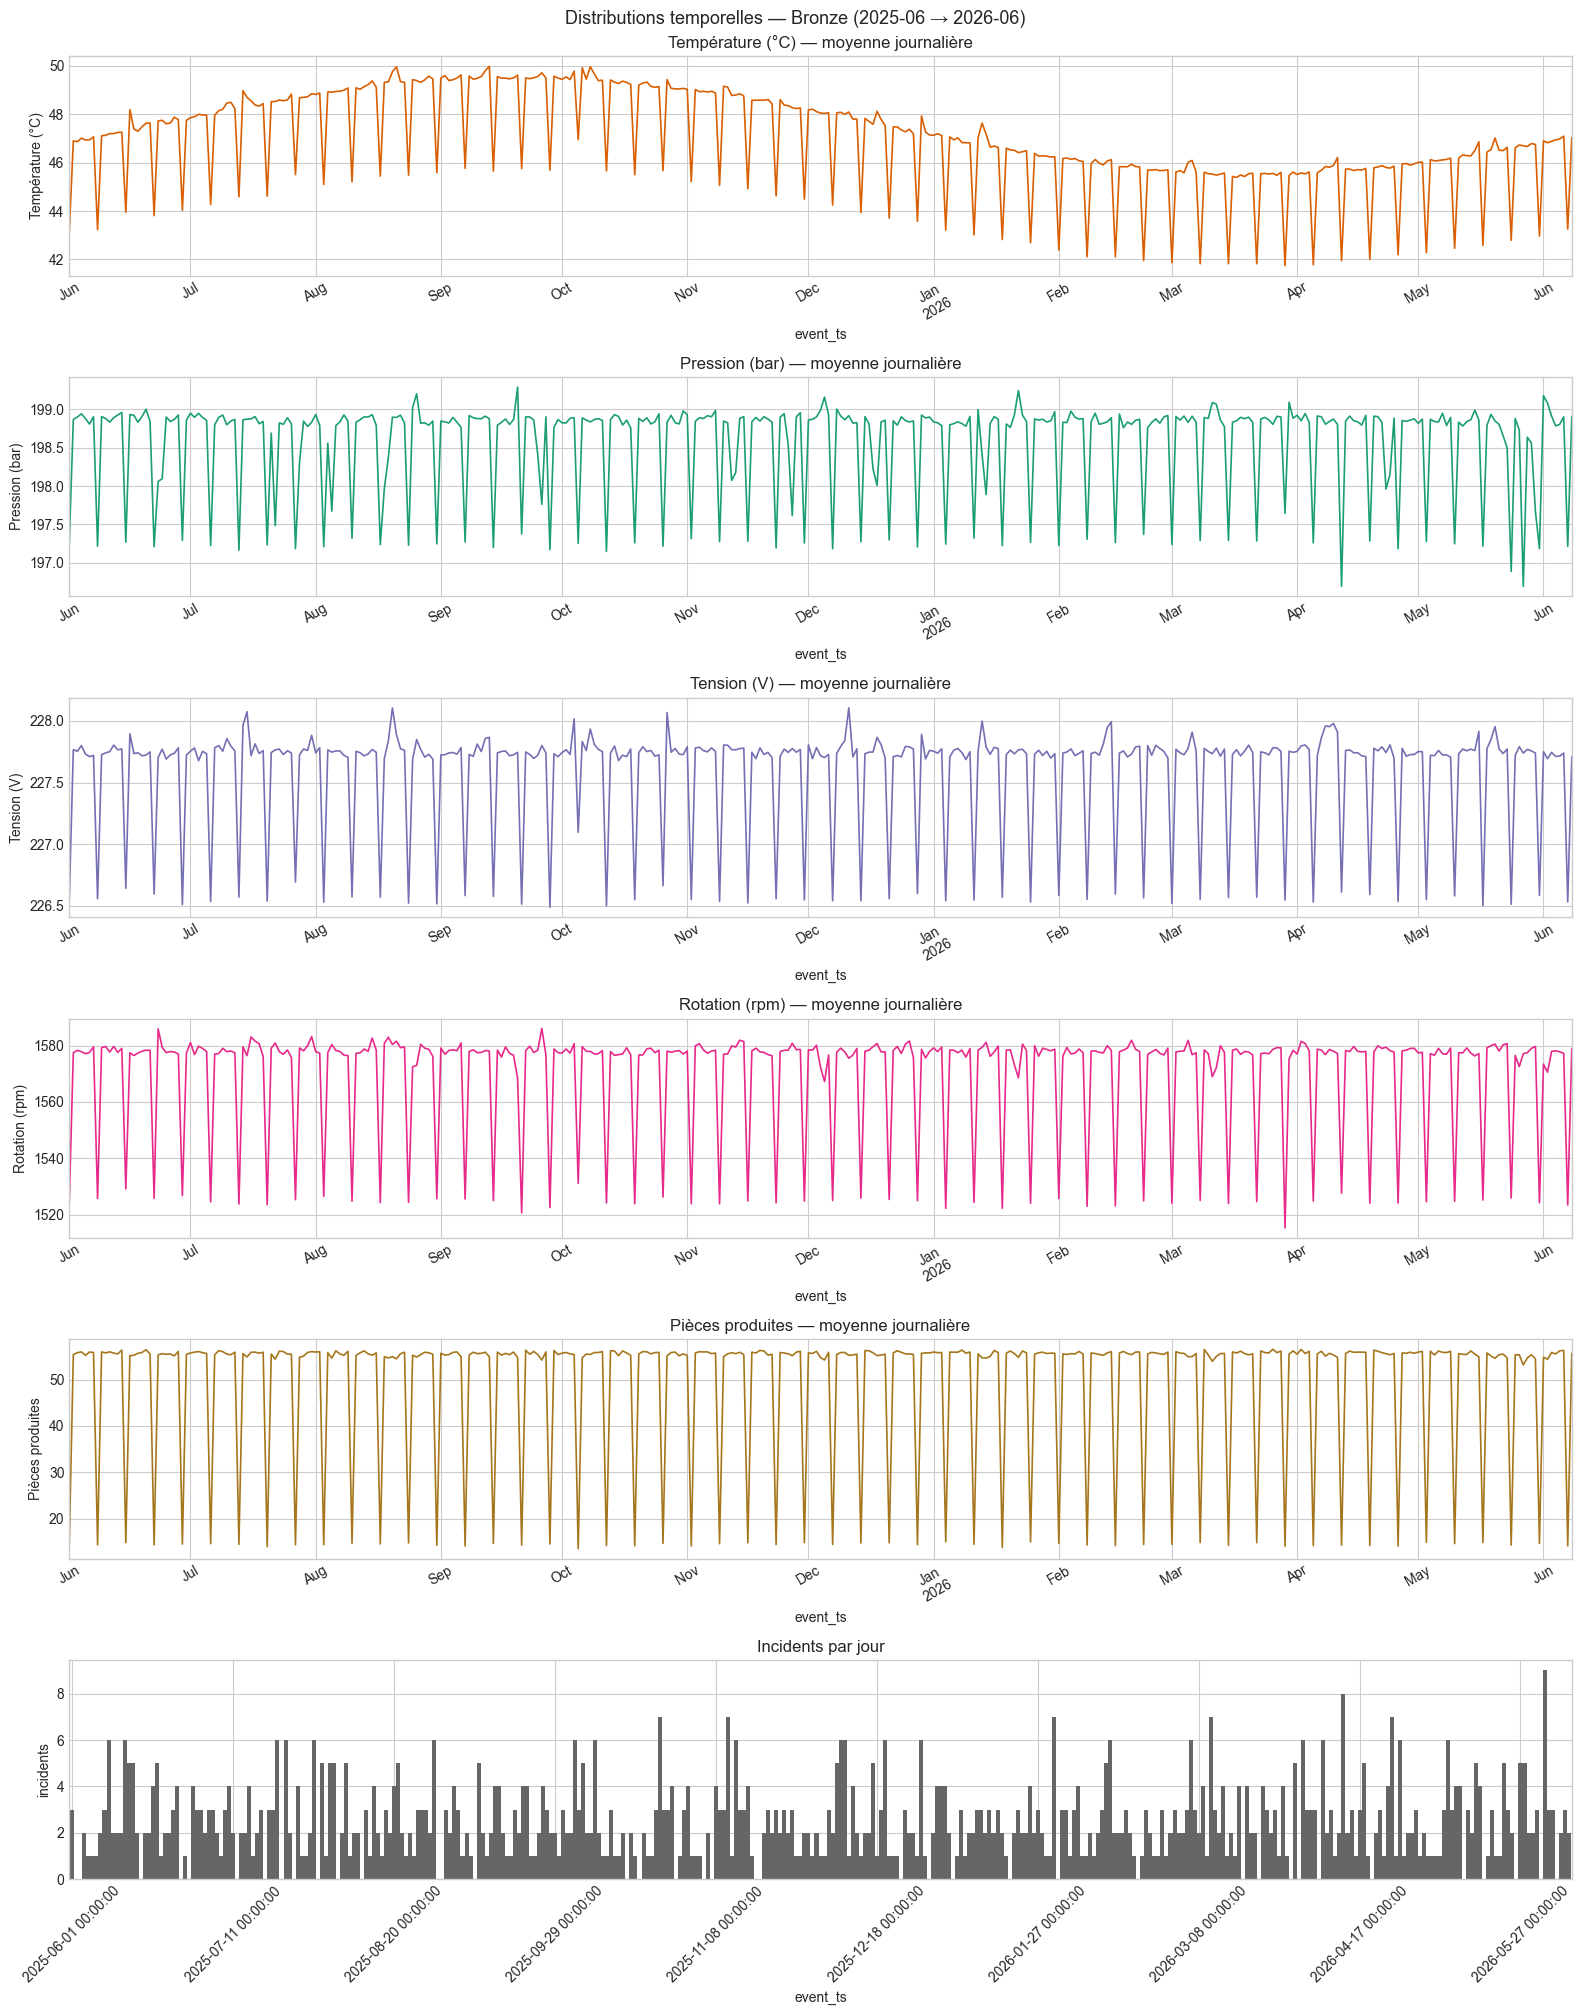

In [8]:
# Agrégations journalières
tel_daily = (
    telemetry_raw.set_index('event_ts')[telemetry_signals]
    .resample('D').mean()
)
inc_daily = (
    incidents_raw.set_index('event_ts').resample('D').size().rename('count')
)

fig, axes = plt.subplots(6, 1, figsize=(16, 20), sharex=False)
colors = ['#d95f02', '#1b9e77', '#7570b3', '#e7298a', '#a6761d']
labels = ['Température (°C)', 'Pression (bar)', 'Tension (V)', 'Rotation (rpm)', 'Pièces produites']

for i, (col, color, label) in enumerate(zip(telemetry_signals, colors, labels)):
    tel_daily[col].plot(ax=axes[i], color=color, linewidth=1.2)
    axes[i].set_title(f'{label} — moyenne journalière')
    axes[i].set_ylabel(label)
    axes[i].tick_params(axis='x', rotation=30)

inc_daily.plot(ax=axes[5], kind='bar', color='#666666', width=1.0)
axes[5].set_title("Incidents par jour")
axes[5].set_ylabel('incidents')
axes[5].tick_params(axis='x', labelrotation=45)
axes[5].xaxis.set_major_locator(mticker.MaxNLocator(nbins=12))

plt.tight_layout()
plt.suptitle('Distributions temporelles — Bronze (2025-06 → 2026-06)', y=1.005, fontsize=13)
plt.show()

## 3. Distribution des relevés d'incidents

Analyse de la répartition des incidents par type, sévérité et machine.

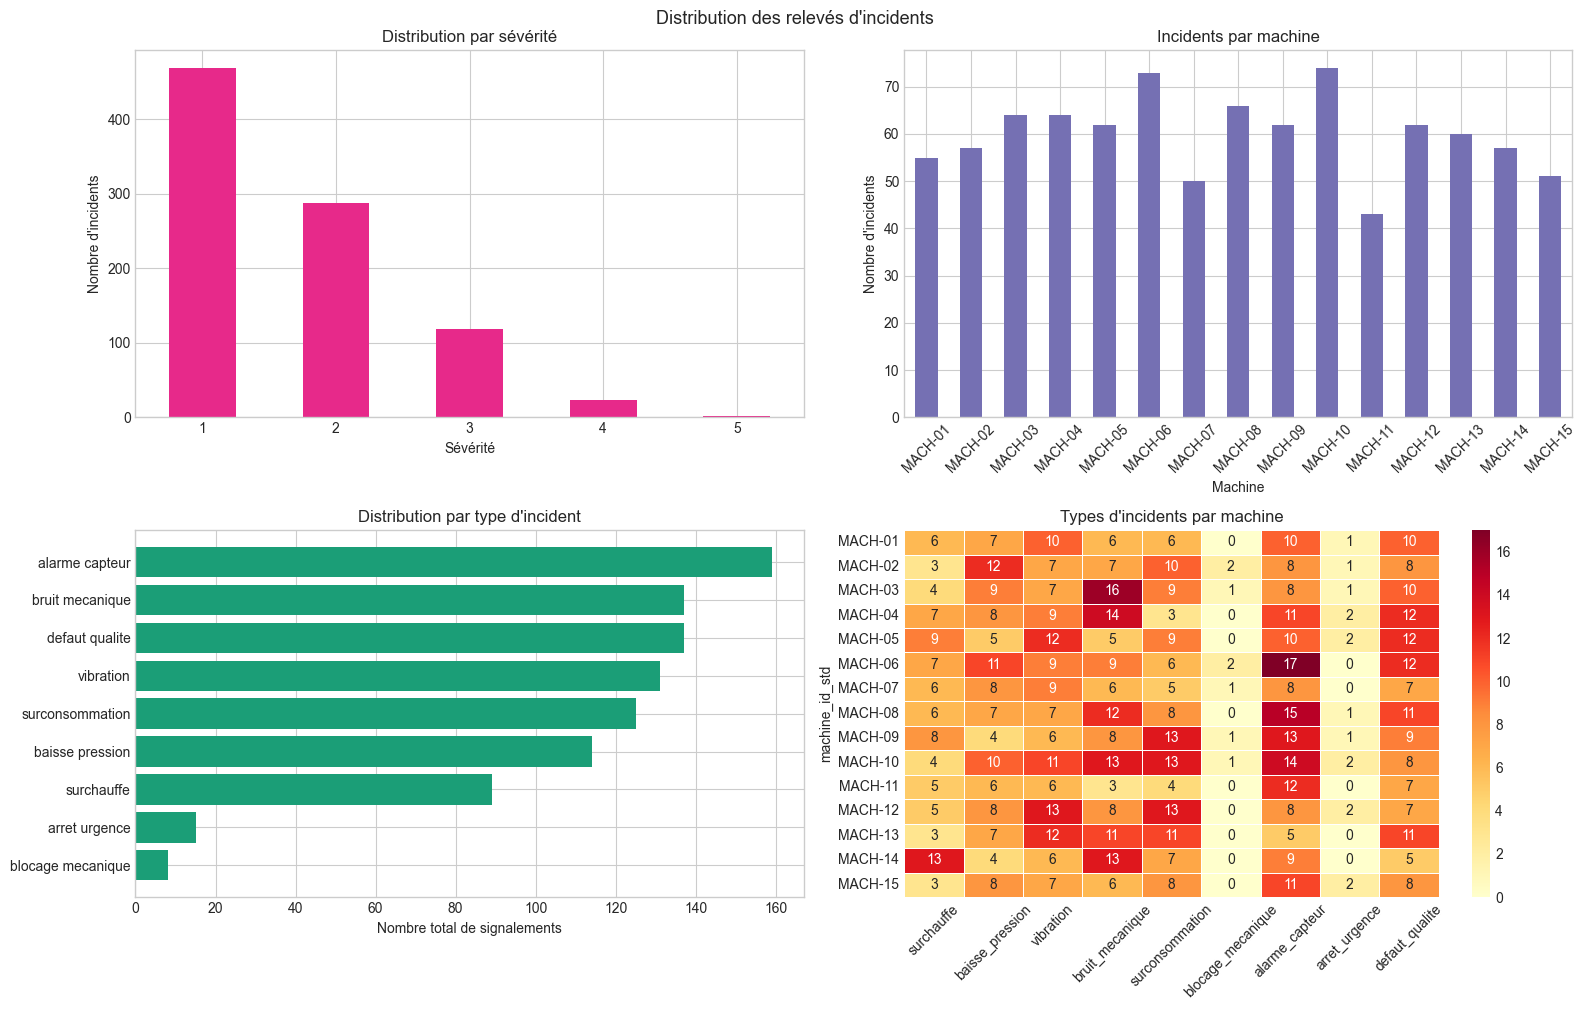

Total incidents : 900
Sévérité moyenne : 1.67
Période : 2025-06-01 → 2026-06-08


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Répartition par sévérité
sev_counts = incidents_raw['severity'].value_counts().sort_index()
sev_counts.plot(kind='bar', ax=axes[0, 0], color='#e7298a')
axes[0, 0].set_title('Distribution par sévérité')
axes[0, 0].set_xlabel('Sévérité')
axes[0, 0].set_ylabel('Nombre d\'incidents')
axes[0, 0].tick_params(axis='x', rotation=0)

# Répartition par machine
machine_counts = incidents_raw['machine_id_std'].value_counts().sort_index()
machine_counts.plot(kind='bar', ax=axes[0, 1], color='#7570b3')
axes[0, 1].set_title('Incidents par machine')
axes[0, 1].set_xlabel('Machine')
axes[0, 1].set_ylabel('Nombre d\'incidents')
axes[0, 1].tick_params(axis='x', rotation=45)

# Répartition par type d'incident
type_sums = incidents_raw[INCIDENT_TYPE_COLS].sum().sort_values(ascending=False)
type_labels = [c.replace('type_', '').replace('_', ' ') for c in type_sums.index]
axes[1, 0].barh(type_labels, type_sums.values, color='#1b9e77')
axes[1, 0].set_title('Distribution par type d\'incident')
axes[1, 0].set_xlabel('Nombre total de signalements')
axes[1, 0].invert_yaxis()

# Heatmap incidents par machine et type
type_by_machine = incidents_raw.groupby('machine_id_std')[INCIDENT_TYPE_COLS].sum()
type_by_machine.columns = [c.replace('type_', '') for c in type_by_machine.columns]
sns.heatmap(type_by_machine, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1, 1], linewidths=0.5)
axes[1, 1].set_title('Types d\'incidents par machine')
axes[1, 1].set_xlabel('')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.suptitle('Distribution des relevés d\'incidents', y=1.005, fontsize=13)
plt.show()

print(f"Total incidents : {len(incidents_raw)}")
print(f"Sévérité moyenne : {incidents_raw['severity'].mean():.2f}")
print(f"Période : {incidents_raw['event_ts'].min().date()} → {incidents_raw['event_ts'].max().date()}")

## 4. Distribution de la télémétrie

Histogrammes et boxplots par machine pour les 5 signaux.

/var/folders/j8/rn3_fl491dl7fkpbvwhxzdk00000gn/T/ipykernel_62190/2722334555.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[row, 1].boxplot(data_by_machine, labels=machine_order, patch_artist=True,
/var/folders/j8/rn3_fl491dl7fkpbvwhxzdk00000gn/T/ipykernel_62190/2722334555.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[row, 1].boxplot(data_by_machine, labels=machine_order, patch_artist=True,
/var/folders/j8/rn3_fl491dl7fkpbvwhxzdk00000gn/T/ipykernel_62190/2722334555.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[row, 1].boxplot(data_by_machine, labels=machine_order, patch

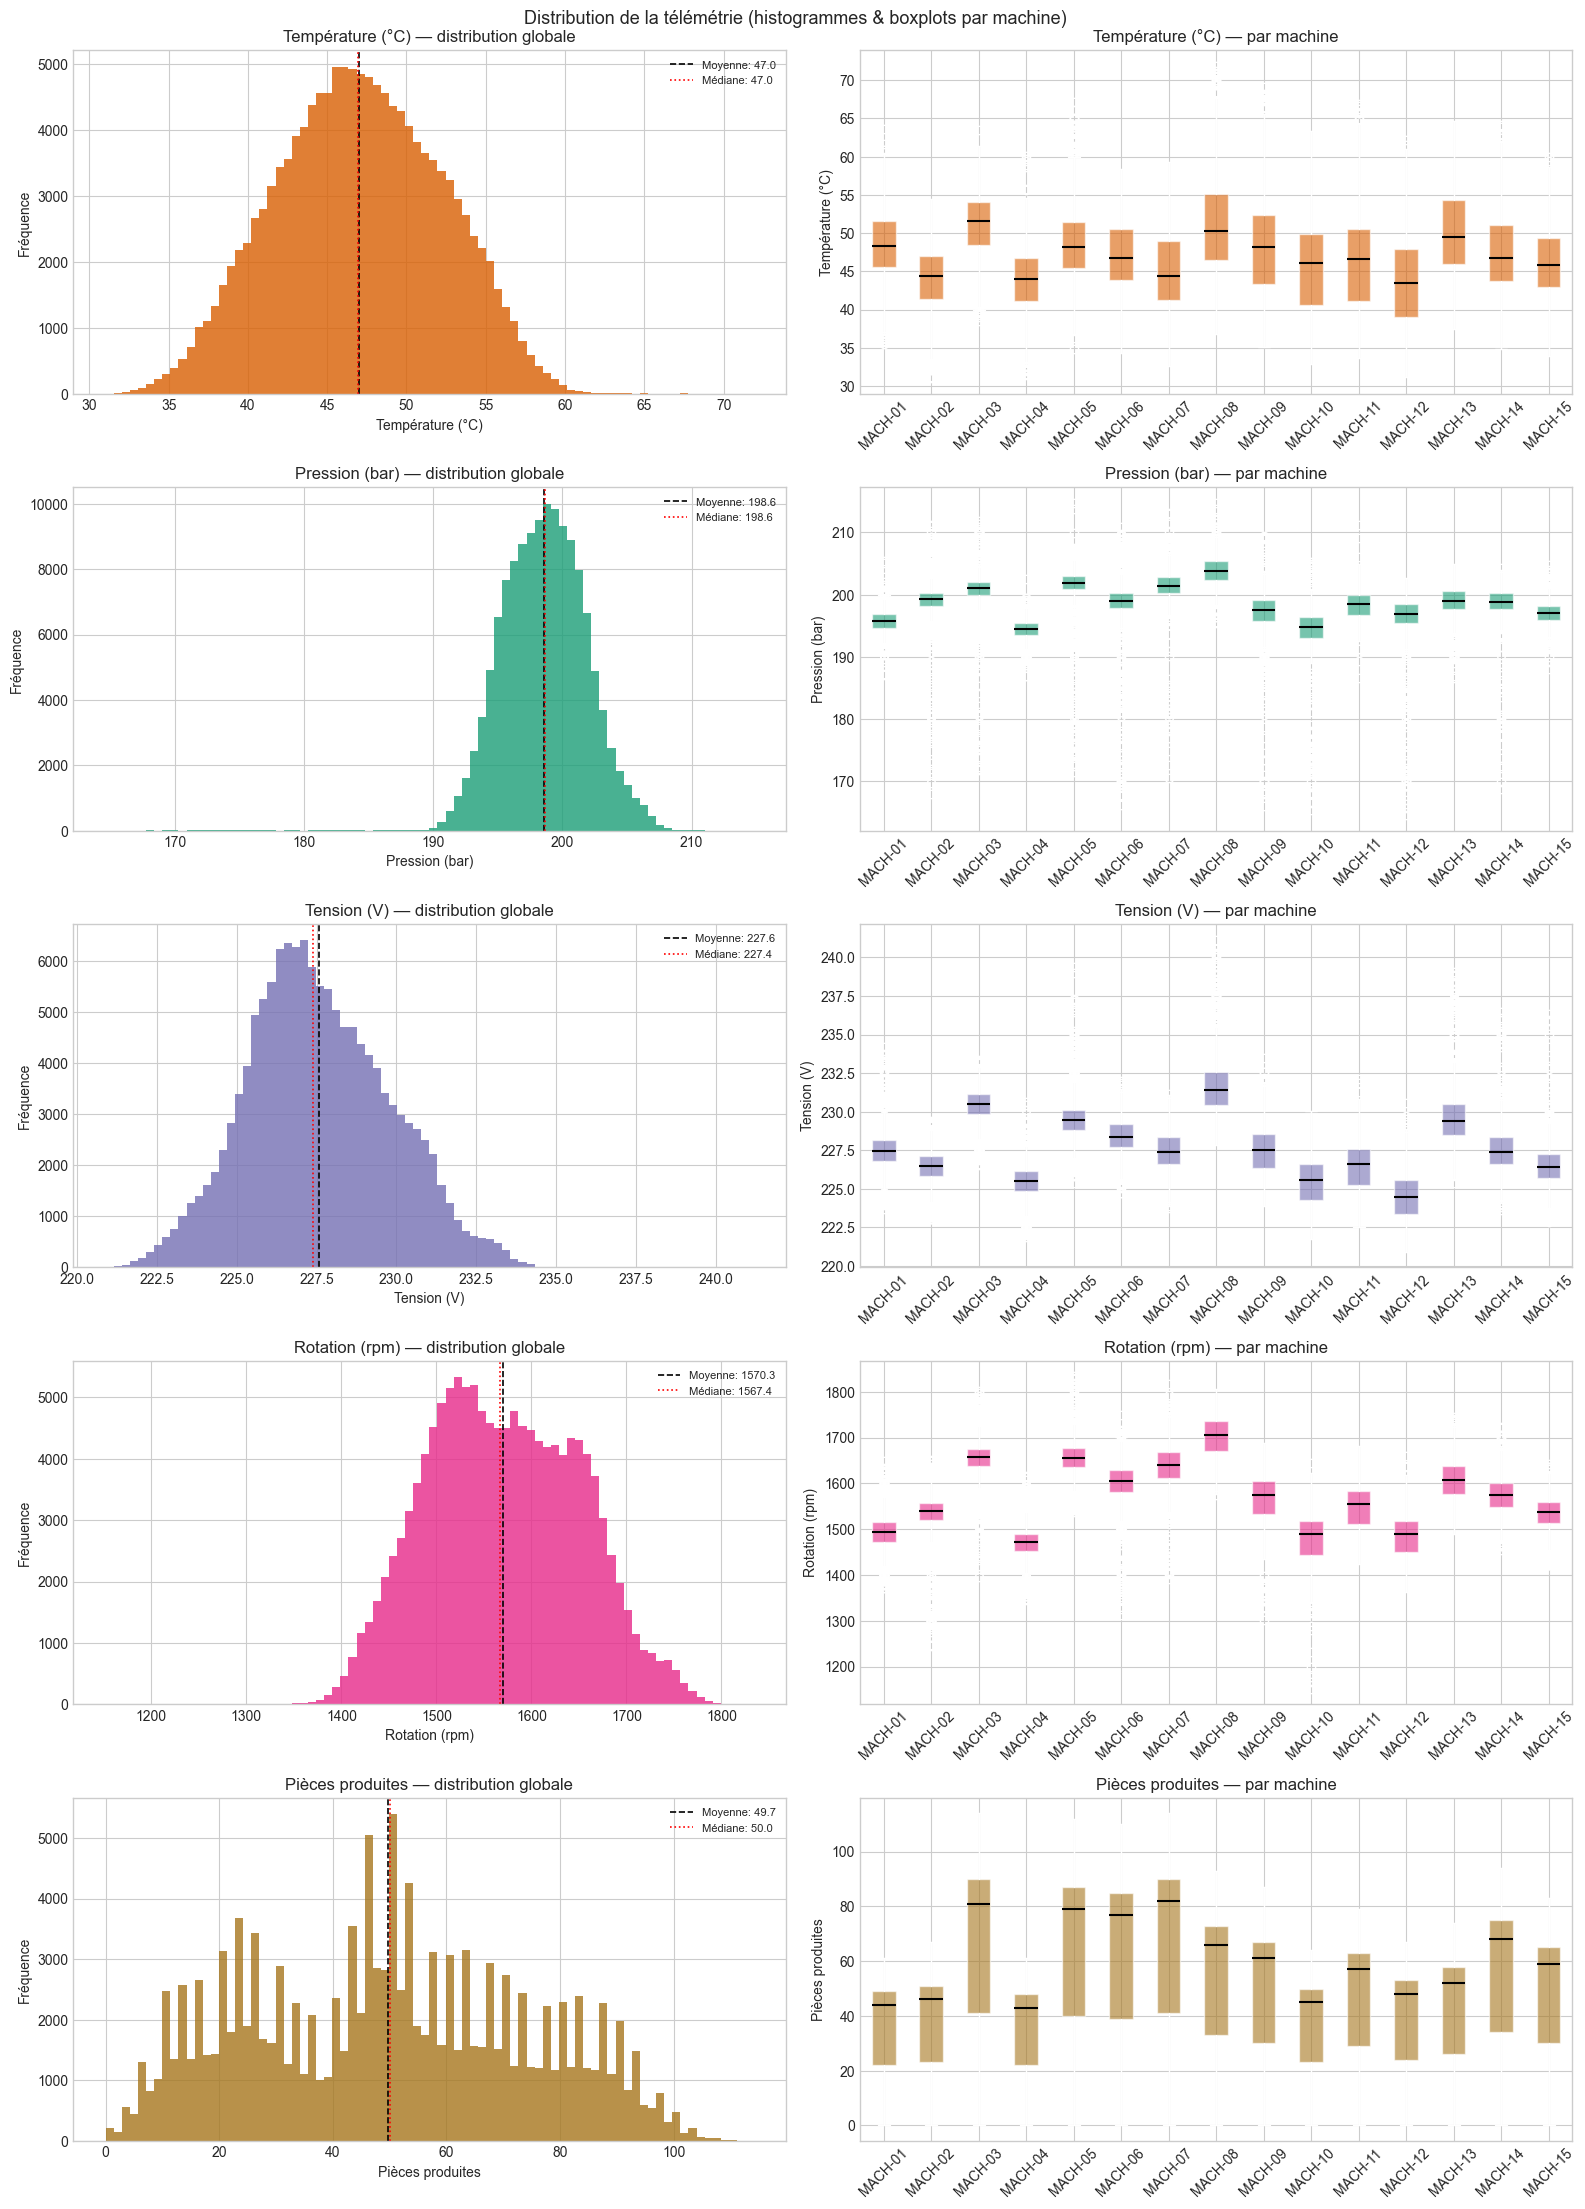

In [10]:
signal_info = [
    ('temperature_c',    'Température (°C)',   '#d95f02'),
    ('pressure_bar',     'Pression (bar)',      '#1b9e77'),
    ('voltage_mean_v',   'Tension (V)',         '#7570b3'),
    ('rotation_mean_rpm','Rotation (rpm)',      '#e7298a'),
    ('pieces_produced',  'Pièces produites',    '#a6761d'),
]

fig, axes = plt.subplots(len(signal_info), 2, figsize=(16, 22))

for row, (col, label, color) in enumerate(signal_info):
    vals = telemetry_raw[col].dropna()

    # Histogramme global
    axes[row, 0].hist(vals, bins=80, color=color, alpha=0.8, edgecolor='none')
    q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
    axes[row, 0].axvline(vals.mean(), color='black', linestyle='--', linewidth=1.2, label=f'Moyenne: {vals.mean():.1f}')
    axes[row, 0].axvline(vals.median(), color='red', linestyle=':', linewidth=1.2, label=f'Médiane: {vals.median():.1f}')
    axes[row, 0].set_title(f'{label} — distribution globale')
    axes[row, 0].set_xlabel(label)
    axes[row, 0].set_ylabel('Fréquence')
    axes[row, 0].legend(fontsize=8)

    # Boxplot par machine
    machine_order = sorted(telemetry_raw['machine_id_std'].unique())
    data_by_machine = [telemetry_raw.loc[telemetry_raw['machine_id_std'] == m, col].dropna().values
                       for m in machine_order]
    bp = axes[row, 1].boxplot(data_by_machine, labels=machine_order, patch_artist=True,
                               medianprops={'color': 'black', 'linewidth': 1.5})
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    axes[row, 1].set_title(f'{label} — par machine')
    axes[row, 1].set_ylabel(label)
    axes[row, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.suptitle('Distribution de la télémétrie (histogrammes & boxplots par machine)', y=1.002, fontsize=13)
plt.show()

## 5. Silver — Normalisation, déduplication, imputation

La couche Silver porte les données **validées, harmonisées et complétées**.
L'ordre de traitement garantit l'absence de biais :

1. Détection et conversion des fenêtres en Fahrenheit ;
2. Déduplication par clé métier `(machine_id, timestamp)` ;
3. Benchmark des stratégies d'imputation sur valeurs masquées ;
4. Application de la meilleure méthode par colonne.

In [11]:
from indusense.core.logging import configure_logging
from indusense.core.settings import DEFAULT_ENV_PATH, get_database_settings
from indusense.db.base import Base
from indusense.processing import (
    ImputationContext,
    build_gold_from_telemetry,
    build_incident_silver_candidate,
    build_sensor_silver_candidate,
    create_artifact_run_dir,
    deduplicate_incidents,
    deduplicate_sensor_records,
    evaluate_imputation_strategies,
    normalize_temperature_units,
    summarize_imputation_decisions,
    write_data_ingestion_report,
)

logger = configure_logging()
artifact_run_dir = create_artifact_run_dir()
print(f'Run artifacts: {artifact_run_dir}')
print('Tables ORM :', sorted(Base.metadata.tables.keys()))

15:52:35 | INFO | Artifact directory created at artifacts/data-ingestion/20260611155235
Run artifacts: artifacts/data-ingestion/20260611155235
Tables ORM : ['bronze_incident_raw', 'bronze_pressure_raw', 'bronze_telemetry_raw', 'bronze_temperature_raw', 'bronze_weather_raw', 'data_quality_issue', 'gold_machine_hourly_feature', 'ingestion_batch', 'machine', 'maintenance', 'operator', 'silver_incident', 'silver_sensor_reading', 'silver_telemetry_reading', 'silver_weather_reading']


### 5.1 Détection et conversion Fahrenheit

Certaines fenêtres temporelles de `temperature_c` présentent des valeurs anormalement élevées
caractéristiques d'une capture en Fahrenheit. La règle est : si la valeur brute est dans
[80, 180] et que sa conversion `(F-32)×5/9` est plus proche du baseline de la machine que la
valeur brute, la fenêtre est convertie.

In [12]:
# La fonction normalize_temperature_units attend 'temperature' comme colonne source
telemetry_for_norm = telemetry_raw.rename(columns={'temperature_c': 'temperature'}).copy()

telemetry_normalized, fahrenheit_windows = normalize_temperature_units(
    telemetry_for_norm,
    value_column='temperature',
)
# Renommer temperature_normalized → temperature_c pour garder la cohérence
telemetry_normalized = telemetry_normalized.rename(columns={'temperature_normalized': 'temperature_c_silver'})

print(f'Fenêtres Fahrenheit détectées : {len(fahrenheit_windows)}')
print(f'Points convertis : {int((telemetry_normalized["detected_unit"] == "F").sum())}')
if not fahrenheit_windows.empty:
    display(fahrenheit_windows.head(10))

15:52:36 | INFO | Temperature normalization converted 0 windows and 0 points
Fenêtres Fahrenheit détectées : 0
Points convertis : 0


### 5.2 Déduplication de la télémétrie

Clé métier : `(machine_id_std, event_ts)`. Pour les doublons stricts (valeurs identiques) on
supprime ; pour les doublons conflictuels on conserve la valeur médiane avec traçabilité.

In [13]:
telemetry_clean, telemetry_dedup_log = deduplicate_sensor_records(
    telemetry_normalized,
    dataset_name='telemetry',
    value_column='temperature_c_silver',
)

incidents_clean, incidents_dedup_log = deduplicate_incidents(
    incidents_raw,
    key_column='incident_id',
)

dedup_summary = pd.DataFrame([
    {
        'source': 'telemetry',
        'avant': len(telemetry_raw),
        'après': len(telemetry_clean),
        'groupes_résolus': len(telemetry_dedup_log),
    },
    {
        'source': 'incidents',
        'avant': len(incidents_raw),
        'après': len(incidents_clean),
        'groupes_résolus': len(incidents_dedup_log),
    },
])
display(dedup_summary)

15:53:08 | INFO | Deduplicated telemetry with 0 duplicate groups resolved
15:53:11 | INFO | Deduplicated incidents with 0 duplicate groups resolved


,source,avant,après,groupes_résolus
0,telemetry,134280,134280,0
1,incidents,900,900,0


### 5.3 Benchmark des stratégies d'imputation

Trois méthodes sont comparées par masquage artificiel (10 % des valeurs observées) :
- `mean` : moyenne par machine ;
- `median` : médiane par machine ;
- `iterative` : `IterativeImputer` multivarié (reconstruit à partir des autres variables).

Métriques : MAE, RMSE, biais, taux hors-plage.

In [14]:
temp_context = ImputationContext(
    dataset_name='telemetry',
    target_column='temperature_c_silver',
    group_column='machine_id_std',
    time_column='event_ts',
    plausible_min=0.0,
    plausible_max=120.0,
)
pressure_context = ImputationContext(
    dataset_name='telemetry_pressure',
    target_column='pressure_bar',
    group_column='machine_id_std',
    time_column='event_ts',
    plausible_min=100.0,
    plausible_max=250.0,
)

temp_metrics, temp_imputed   = evaluate_imputation_strategies(telemetry_clean, context=temp_context)
press_metrics, press_imputed = evaluate_imputation_strategies(telemetry_clean, context=pressure_context)

imputation_metrics = pd.concat([temp_metrics, press_metrics], ignore_index=True)
imputation_decisions = summarize_imputation_decisions(imputation_metrics)

print('=== Métriques par méthode ===')
display(imputation_metrics[['dataset_name', 'target_column', 'method', 'mae', 'rmse', 'bias', 'out_of_range_rate']])
print('=== Décisions retenues ===')
display(imputation_decisions[['dataset_name', 'target_column', 'recommended_method', 'mae', 'rmse']])

=== Métriques par méthode ===


,dataset_name,target_column,method,mae,rmse,bias,out_of_range_rate
0,telemetry,temperature_c_silver,mean,3.899169,4.660622,-0.006054,0.0
1,telemetry,temperature_c_silver,median,3.881871,4.670950,-0.054097,0.0
2,telemetry,temperature_c_silver,iterative,4.131939,5.017144,-0.019524,0.0
3,telemetry_pressure,pressure_bar,mean,1.529475,2.162860,0.005709,0.0
4,telemetry_pressure,pressure_bar,median,1.525803,2.165996,0.042065,0.0
5,telemetry_pressure,pressure_bar,iterative,2.597386,3.346606,-0.036199,0.0


=== Décisions retenues ===


,dataset_name,target_column,recommended_method,mae,rmse
0,telemetry,temperature_c_silver,mean,3.899169,4.660622
1,telemetry_pressure,pressure_bar,mean,1.529475,2.162860


### 5.4 Construction des candidats Silver

In [15]:
temp_method = imputation_decisions.loc[
    imputation_decisions['dataset_name'].eq('telemetry'), 'recommended_method'
].iloc[0]
press_method = imputation_decisions.loc[
    imputation_decisions['dataset_name'].eq('telemetry_pressure'), 'recommended_method'
].iloc[0]

# Silver télémétrie : on réunit les valeurs imputées pour temp + pressure dans le même DF
telemetry_silver = telemetry_clean.copy()
telemetry_silver['temperature_c'] = telemetry_silver['temperature_c_silver'].fillna(
    temp_imputed.get(f'temperature_c_silver_{temp_method}',
                     telemetry_silver['temperature_c_silver'])
)
telemetry_silver['pressure_bar'] = telemetry_silver['pressure_bar'].fillna(
    press_imputed.get(f'pressure_bar_{press_method}',
                      telemetry_silver['pressure_bar'])
)
# Renommer event_ts → sensor_value pour compatibilité build_gold_from_telemetry
telemetry_silver['sensor_value'] = telemetry_silver['temperature_c']
telemetry_silver['is_missing'] = telemetry_silver['temperature_c_silver'].isna()

# Silver incidents
incident_silver = build_incident_silver_candidate(incidents_clean)
incident_silver = incident_silver.rename(columns={'incident_id': 'incident_id_code'})
# Ajouter une clé incident_id compatible avec build_gold_from_telemetry
incident_silver['incident_id'] = incident_silver['incident_id_code']

# Propagation des colonnes type_* depuis incidents_clean
for col in INCIDENT_TYPE_COLS:
    if col in incidents_clean.columns:
        incident_silver[col] = incidents_clean[col].values

silver_overview = pd.DataFrame([
    {
        'layer': 'silver_telemetry',
        'rows': len(telemetry_silver),
        'rows_imputed_temp': int(telemetry_silver['is_missing'].sum()),
        'duplicates_flagged': int(telemetry_silver.get('is_duplicate', pd.Series([False])).sum()),
    },
    {
        'layer': 'silver_incidents',
        'rows': len(incident_silver),
        'rows_imputed_temp': 0,
        'duplicates_flagged': int(incident_silver.get('is_duplicate', pd.Series([False])).sum()),
    },
])
display(silver_overview)

,layer,rows,rows_imputed_temp,duplicates_flagged
0,silver_telemetry,134280,0,0
1,silver_incidents,900,0,0


## 6. Gold — Dataset multi-horizons prêt à l'entraînement

Le Gold Dataset est construit à partir des candidats Silver. Les fenêtres temporelles
sont calculées **par machine** pour éviter le data leakage inter-machine.

**Features produites :**
- Rolling mean/max/std pour temperature, pressure, voltage, rotation à 6h/12h/24h ;
- Tendances (delta 6h) ;
- Z-score anomalie 24h sur la température ;
- Lookback incidents : count 24h/7j, max sévérité 24h, heures depuis dernier incident ;
- Counts 24h par type d'incident (9 types) ;
- Production 24h + taux d'utilisation capacité ;
- Maintenance : jours depuis dernière, count 30j ;
- Labels `label_failure_next_Xh` pour X ∈ {6, 12, 24, 48}.

In [16]:
# Machine metadata pour la capacité horaire
machine_meta = machines_df[['machine_code', 'max_hourly_capacity_pieces', 'criticality']].copy()
machine_meta = machine_meta.rename(columns={'machine_code': 'machine_id_std'})

gold = build_gold_from_telemetry(
    telemetry_silver=telemetry_silver,
    incident_silver=incident_silver,
    machine_meta=machine_meta,
    maintenance_df=maintenance_df,
)

print(f'Gold dataset : {gold.shape[0]:,} lignes × {gold.shape[1]} colonnes'.replace(',', ' '))
print(f'Période : {gold["window_start"].min()} → {gold["window_start"].max()}')
print(f'Machines : {sorted(gold["machine_id_std"].unique())}')
print()
print('Répartition split_set :')
display(gold['split_set'].value_counts())
display(gold.head(10))

15:53:31 | INFO | Gold (telemetry) dataset built with 134280 rows
Gold dataset : 134 280 lignes × 90 colonnes
Période : 2025-06-01 00:00:00 → 2026-06-08 23:00:00
Machines : ['MACH-01', 'MACH-02', 'MACH-03', 'MACH-04', 'MACH-05', 'MACH-06', 'MACH-07', 'MACH-08', 'MACH-09', 'MACH-10', 'MACH-11', 'MACH-12', 'MACH-13', 'MACH-14', 'MACH-15']

Répartition split_set :


split_set
train         93990
validation    20145
test          20145
Name: count, dtype: int64

,machine_id_std,window_start,temp_mean_1h,temp_max_1h,pressure_mean_1h,pressure_max_1h,voltage_mean_1h,voltage_max_1h,rotation_mean_1h,rotation_max_1h,pieces_produced_sum_1h,window_end,temp_mean_6h,temp_max_6h,temp_std_6h,pressure_mean_6h,pressure_max_6h,pressure_std_6h,voltage_mean_6h,voltage_max_6h,...,type_surchauffe_count_prev_24h,type_baisse_pression_count_prev_24h,type_vibration_count_prev_24h,type_bruit_mecanique_count_prev_24h,type_surconsommation_count_prev_24h,type_blocage_mecanique_count_prev_24h,type_alarme_capteur_count_prev_24h,type_arret_urgence_count_prev_24h,type_defaut_qualite_count_prev_24h,days_since_last_maintenance,maintenance_count_prev_30d,future_incident_count_6h,label_failure_next_6h,future_incident_count_12h,label_failure_next_12h,future_incident_count_24h,label_failure_next_24h,future_incident_count_48h,label_failure_next_48h,split_set
0,MACH-01,2025-06-01 00:00:00,45.44,45.44,194.302,194.302,227.57,227.57,1441.7,1441.7,4,2025-06-01 01:00:00,45.440000,45.44,NaN,194.302000,194.302,NaN,227.570000,227.57,...,0,0,0,0,0,0,0,0,0,NaN,0,0.0,False,0.0,False,0.0,False,0.0,False,train
1,MACH-01,2025-06-01 01:00:00,47.87,47.87,194.391,194.391,227.48,227.48,1437.8,1437.8,4,2025-06-01 02:00:00,46.655000,47.87,1.718269,194.346500,194.391,0.062933,227.525000,227.57,...,0,0,0,0,0,0,0,0,0,NaN,0,0.0,False,0.0,False,0.0,False,0.0,False,train
2,MACH-01,2025-06-01 02:00:00,50.46,50.46,195.641,195.641,228.68,228.68,1484.6,1484.6,13,2025-06-01 03:00:00,47.923333,50.46,2.510425,194.778000,195.641,0.748704,227.910000,228.68,...,0,0,0,0,0,0,0,0,0,NaN,0,0.0,False,0.0,False,0.0,False,0.0,False,train
3,MACH-01,2025-06-01 03:00:00,48.62,48.62,197.737,197.737,228.44,228.44,1488.9,1488.9,10,2025-06-01 04:00:00,48.097500,50.46,2.079140,195.517750,197.737,1.600820,228.042500,228.68,...,0,0,0,0,0,0,0,0,0,NaN,0,0.0,False,0.0,False,0.0,False,0.0,False,train
4,MACH-01,2025-06-01 04:00:00,51.09,51.09,196.253,196.253,227.84,227.84,1448.6,1448.6,6,2025-06-01 05:00:00,48.696000,51.09,2.243464,195.664800,197.737,1.424811,228.002000,228.68,...,0,0,0,0,0,0,0,0,0,NaN,0,0.0,False,0.0,False,0.0,False,0.0,False,train
5,MACH-01,2025-06-01 05:00:00,49.51,49.51,196.010,196.010,227.50,227.50,1454.7,1454.7,4,2025-06-01 06:00:00,48.831667,51.09,2.033946,195.722333,197.737,1.282158,227.918333,228.68,...,0,0,0,0,0,0,0,0,0,NaN,0,0.0,False,0.0,False,0.0,False,0.0,False,train
6,MACH-01,2025-06-01 06:00:00,48.84,48.84,194.647,194.647,227.65,227.65,1455.7,1455.7,7,2025-06-01 07:00:00,49.398333,51.09,1.204548,195.779833,197.737,1.211512,227.931667,228.68,...,0,0,0,0,0,0,0,0,0,NaN,0,0.0,False,0.0,False,0.0,False,0.0,False,train
7,MACH-01,2025-06-01 07:00:00,49.40,49.40,196.068,196.068,226.89,226.89,1493.8,1493.8,19,2025-06-01 08:00:00,49.653333,51.09,0.951707,196.059333,197.737,1.002424,227.833333,228.68,...,0,0,0,0,0,0,0,0,0,NaN,0,0.0,False,0.0,False,0.0,False,0.0,False,train
8,MACH-01,2025-06-01 08:00:00,47.78,47.78,196.358,196.358,226.05,226.05,1467.8,1467.8,12,2025-06-01 09:00:00,49.206667,51.09,1.112684,196.178833,197.737,0.985169,227.395000,228.44,...,0,0,0,0,0,0,0,0,0,NaN,0,0.0,False,0.0,False,0.0,False,0.0,False,train
9,MACH-01,2025-06-01 09:00:00,45.80,45.80,195.147,195.147,225.11,225.11,1432.0,1432.0,5,2025-06-01 10:00:00,48.736667,51.09,1.795892,195.747167,196.358,0.688704,226.840000,227.84,...,0,0,0,0,0,0,0,0,0,NaN,0,0.0,False,0.0,False,0.0,False,0.0,False,train


### 6.1 Aperçu des features Gold

In [17]:
label_cols = [c for c in gold.columns if c.startswith('label_')]
feature_cols = [
    c for c in gold.columns
    if c not in label_cols
    and c not in ('machine_id_std', 'window_start', 'window_end', 'split_set')
    and not c.startswith('future_')
    and not c.startswith('type_') and not c.endswith('_1h')
]

print(f'{len(feature_cols)} features × {len(label_cols)} labels')
print('\nFeatures :')
print(feature_cols)
print('\nLabels :')
print(label_cols)

# Statistiques des features numériques
display(gold[feature_cols].describe().T.round(3))

49 features × 4 labels

Features :
['temp_mean_6h', 'temp_max_6h', 'temp_std_6h', 'pressure_mean_6h', 'pressure_max_6h', 'pressure_std_6h', 'voltage_mean_6h', 'voltage_max_6h', 'voltage_std_6h', 'rotation_mean_6h', 'rotation_max_6h', 'rotation_std_6h', 'temp_mean_12h', 'temp_max_12h', 'temp_std_12h', 'pressure_mean_12h', 'pressure_max_12h', 'pressure_std_12h', 'voltage_mean_12h', 'voltage_max_12h', 'voltage_std_12h', 'rotation_mean_12h', 'rotation_max_12h', 'rotation_std_12h', 'temp_mean_24h', 'temp_max_24h', 'temp_std_24h', 'pressure_mean_24h', 'pressure_max_24h', 'pressure_std_24h', 'voltage_mean_24h', 'voltage_max_24h', 'voltage_std_24h', 'rotation_mean_24h', 'rotation_max_24h', 'rotation_std_24h', 'temp_trend_6h', 'pressure_trend_6h', 'voltage_trend_6h', 'rotation_trend_6h', 'temp_zscore_24h', 'pieces_produced_sum_24h', 'capacity_utilization_pct', 'incident_count_prev_24h', 'incident_max_severity_prev_24h', 'incident_count_prev_7d', 'hours_since_last_incident', 'days_since_last_mai

,count,mean,std,min,25%,50%,75%,max
temp_mean_6h,134280.0,47.020,4.808,33.120,43.560,46.958,50.567,70.643
temp_max_6h,134280.0,49.752,4.835,33.950,46.340,49.840,53.412,71.870
temp_std_6h,134265.0,2.092,0.866,0.028,1.437,2.015,2.625,11.907
pressure_mean_6h,134280.0,198.584,3.115,167.215,196.369,198.600,200.722,211.014
pressure_max_6h,134280.0,200.076,3.149,170.073,197.847,200.078,202.180,214.775
pressure_std_6h,134265.0,1.125,0.521,0.023,0.830,1.074,1.348,17.523
voltage_mean_6h,134280.0,227.592,2.144,221.450,226.077,227.370,229.012,240.133
voltage_max_6h,134280.0,228.533,2.166,221.450,226.990,228.310,229.950,241.160
voltage_std_6h,134265.0,0.710,0.262,0.047,0.526,0.683,0.862,5.595
rotation_mean_6h,134280.0,1570.320,76.398,1200.867,1512.050,1566.567,1633.100,1819.050


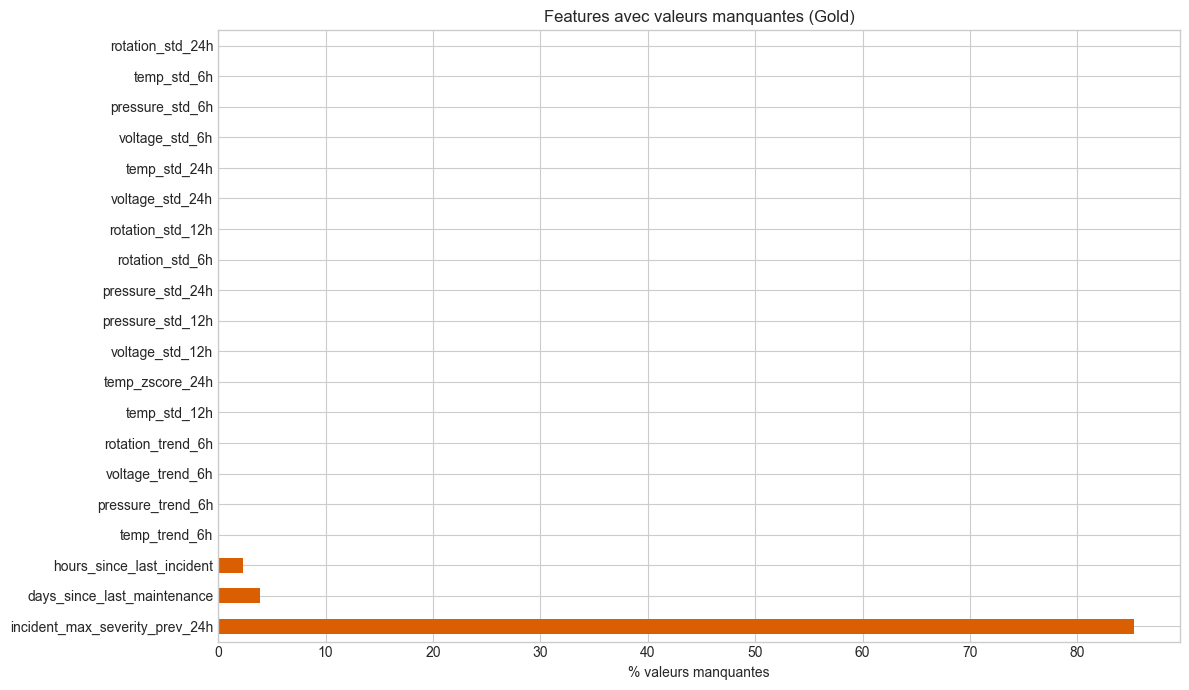

Couverture features : 29/49 colonnes sans NaN


In [18]:
# Taux de valeurs manquantes par feature
missing_pct = (gold[feature_cols].isnull().mean() * 100).sort_values(ascending=False)
missing_nonzero = missing_pct[missing_pct > 0]

if not missing_nonzero.empty:
    fig, ax = plt.subplots(figsize=(12, max(3, len(missing_nonzero) * 0.35)))
    missing_nonzero.plot(kind='barh', ax=ax, color='#d95f02')
    ax.set_xlabel('% valeurs manquantes')
    ax.set_title('Features avec valeurs manquantes (Gold)')
    plt.tight_layout()
    plt.show()
else:
    print('Aucune valeur manquante dans les features Gold !')

print(f'Couverture features : {(missing_pct == 0).sum()}/{len(feature_cols)} colonnes sans NaN')

## 7. Matrice de corrélation des features Gold

Cette vue vérifie l'absence de colinéarité excessive et identifie les features les plus
corrélées aux labels cibles.

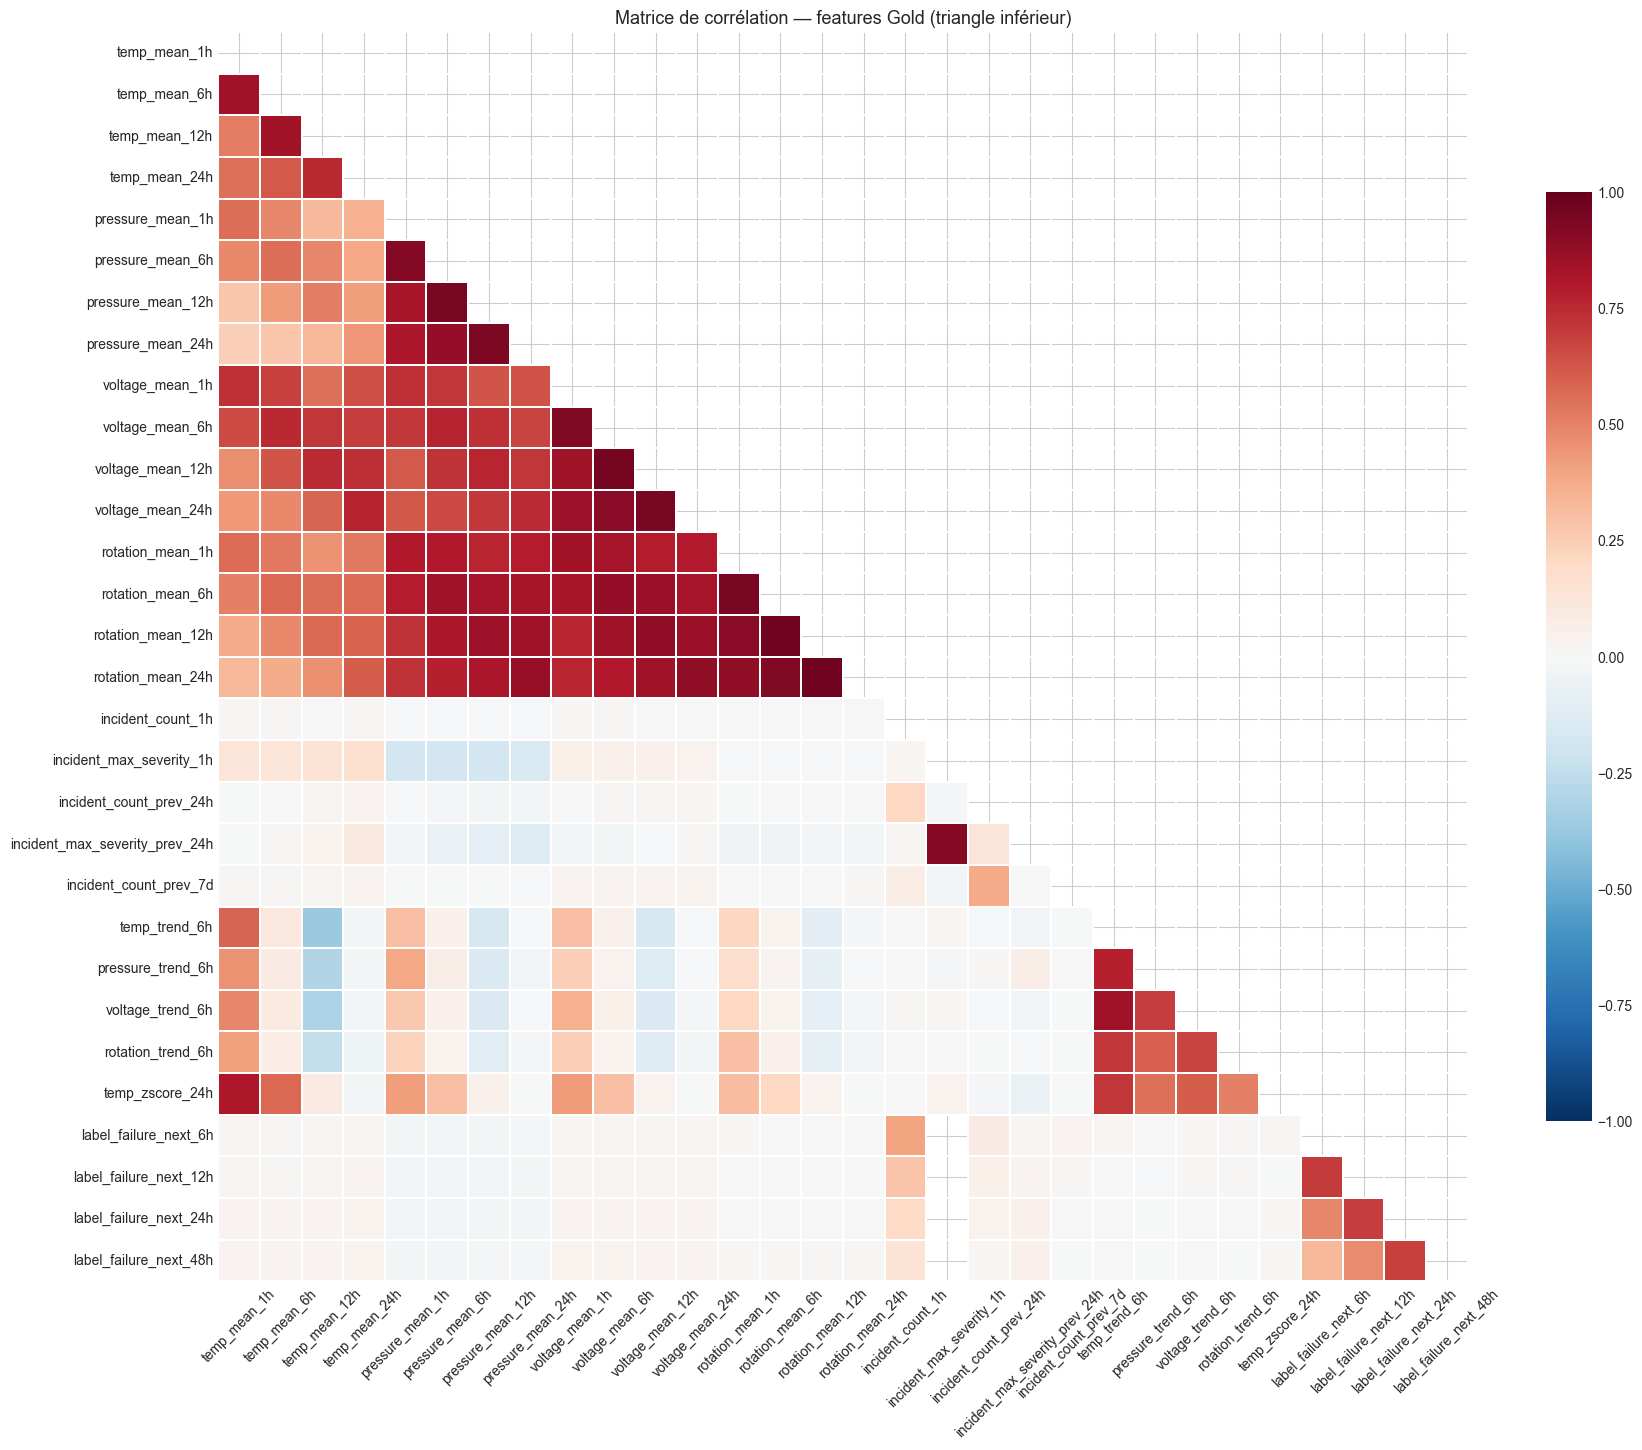

Top 10 features corrélées à label_failure_next_24h :


incident_count_1h                 0.1965
incident_max_severity_prev_24h    0.0527
incident_count_prev_24h           0.0397
pressure_mean_1h                  0.0324
pressure_mean_6h                  0.0321
temp_mean_24h                     0.0321
voltage_mean_1h                   0.0304
pressure_mean_12h                 0.0304
voltage_mean_6h                   0.0297
temp_mean_12h                     0.0296
Name: label_failure_next_24h, dtype: float64

In [19]:
# Sélection des features numériques principales (exclure les colonnes intermédiaires)
corr_cols = [
    c for c in gold.columns
    if gold[c].dtype in ('float64', 'int64', 'float32', 'int32')
    and not c.startswith('future_')
    and c not in ('maintenance_count_prev_30d',)
    and gold[c].nunique() > 1
]
# Limiter à 35 colonnes pour la lisibilité
priority = (
    [c for c in corr_cols if c.startswith('temp_mean')]
    + [c for c in corr_cols if c.startswith('pressure_mean')]
    + [c for c in corr_cols if c.startswith('voltage_mean')]
    + [c for c in corr_cols if c.startswith('rotation_mean')]
    + [c for c in corr_cols if 'incident_count' in c or 'severity' in c]
    + [c for c in corr_cols if 'zscore' in c or 'trend' in c]
    + label_cols
)
seen = set()
priority_dedup = [c for c in priority if c in gold.columns and c not in seen and not seen.add(c)]
corr_cols_final = priority_dedup[:35]

corr_matrix = gold[corr_cols_final].corr()

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=False, cmap='RdBu_r',
    vmin=-1, vmax=1, center=0, square=True, linewidths=0.3,
    ax=ax, cbar_kws={'shrink': 0.7},
)
ax.set_title('Matrice de corrélation — features Gold (triangle inférieur)', fontsize=13)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

# Top corrélations avec les labels
if label_cols:
    print('Top 10 features corrélées à label_failure_next_24h :')
    top_corr = (
        corr_matrix['label_failure_next_24h']
        .drop(label_cols, errors='ignore')
        .abs()
        .sort_values(ascending=False)
        .head(10)
    )
    display(top_corr.round(4))

## 8. Équilibre des classes

Le déséquilibre de classes est une caractéristique attendue pour un problème de prédiction
de panne : les pannes sont rares. Ce graphe quantifie ce déséquilibre pour chaque horizon
de prédiction et confirme que le Gold Dataset est exploitable (ratio < 1:20).

,horizon,positifs,négatifs,total,taux_positifs_%,ratio_neg_pos
0,6h,5275,129005,134280,3.93,24.5
1,12h,10311,123969,134280,7.68,12.0
2,24h,19744,114536,134280,14.70,5.8
3,48h,36460,97820,134280,27.15,2.7


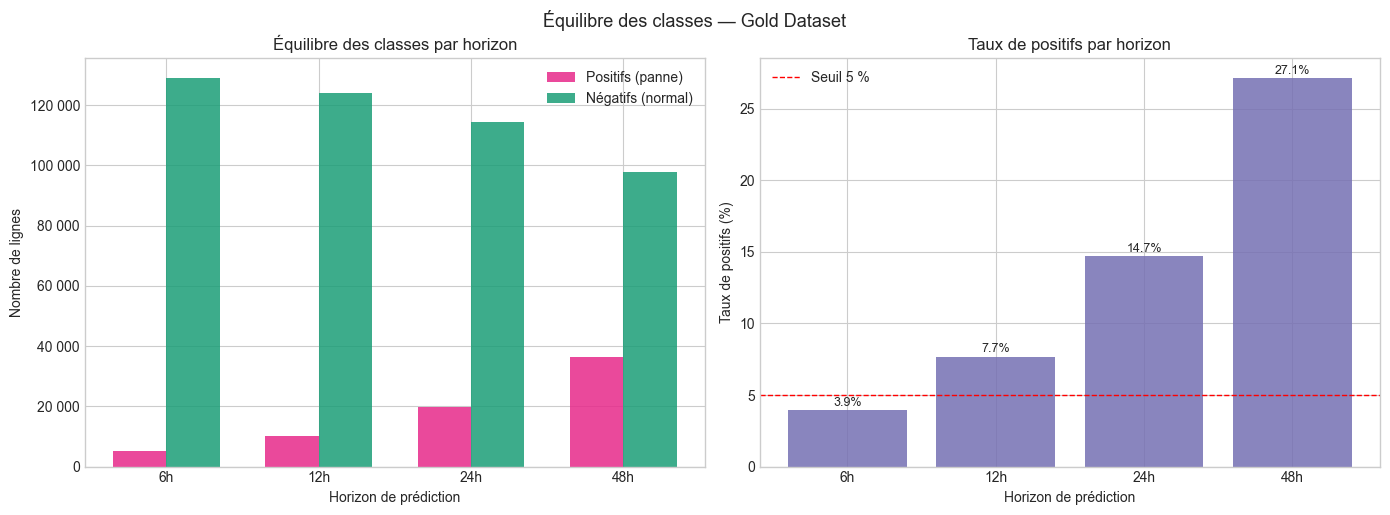


Répartition split_set × label_failure_next_24h :


,positifs,total,taux
split_set,,,
test,3097,20145,15.37
train,13581,93990,14.45
validation,3066,20145,15.22


In [20]:
horizons = [6, 12, 24, 48]
balance_rows = []
for h in horizons:
    col = f'label_failure_next_{h}h'
    if col not in gold.columns:
        continue
    pos = int(gold[col].sum())
    total = len(gold)
    balance_rows.append({
        'horizon': f'{h}h',
        'positifs': pos,
        'négatifs': total - pos,
        'total': total,
        'taux_positifs_%': round(pos / total * 100, 2),
        'ratio_neg_pos': round((total - pos) / max(pos, 1), 1),
    })

balance_df = pd.DataFrame(balance_rows)
display(balance_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barres positifs/négatifs
x = np.arange(len(balance_df))
width = 0.35
axes[0].bar(x - width/2, balance_df['positifs'],  width, label='Positifs (panne)', color='#e7298a', alpha=0.85)
axes[0].bar(x + width/2, balance_df['négatifs'], width, label='Négatifs (normal)', color='#1b9e77', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(balance_df['horizon'])
axes[0].set_xlabel('Horizon de prédiction')
axes[0].set_ylabel('Nombre de lignes')
axes[0].set_title('Équilibre des classes par horizon')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'.replace(',', ' ')))

# Taux de positifs
axes[1].bar(balance_df['horizon'], balance_df['taux_positifs_%'], color='#7570b3', alpha=0.85)
axes[1].axhline(5, color='red', linestyle='--', linewidth=1, label='Seuil 5 %')
for i, row in balance_df.iterrows():
    axes[1].text(i, row['taux_positifs_%'] + 0.3, f"{row['taux_positifs_%']:.1f}%", ha='center', fontsize=9)
axes[1].set_xlabel('Horizon de prédiction')
axes[1].set_ylabel('Taux de positifs (%)')
axes[1].set_title('Taux de positifs par horizon')
axes[1].legend()

plt.tight_layout()
plt.suptitle('Équilibre des classes — Gold Dataset', y=1.02, fontsize=13)
plt.show()

# Répartition par split_set
print('\nRépartition split_set × label_failure_next_24h :')
pivot = gold.groupby('split_set')['label_failure_next_24h'].agg(
    positifs='sum', total='count'
).assign(taux=lambda d: (d['positifs']/d['total']*100).round(2))
display(pivot)

## 9. Fenêtres temporelles et couverture

,source,start,end,rows
0,telemetry,2025-06-01 00:00:00,2026-06-08 23:00:00,134280
1,incidents,2025-06-01 05:00:00,2026-06-08 17:00:00,900
2,maintenance,2025-06-15 06:00:00,2026-05-30 22:00:00,115
3,gold,2025-06-01 00:00:00,2026-06-08 23:00:00,134280


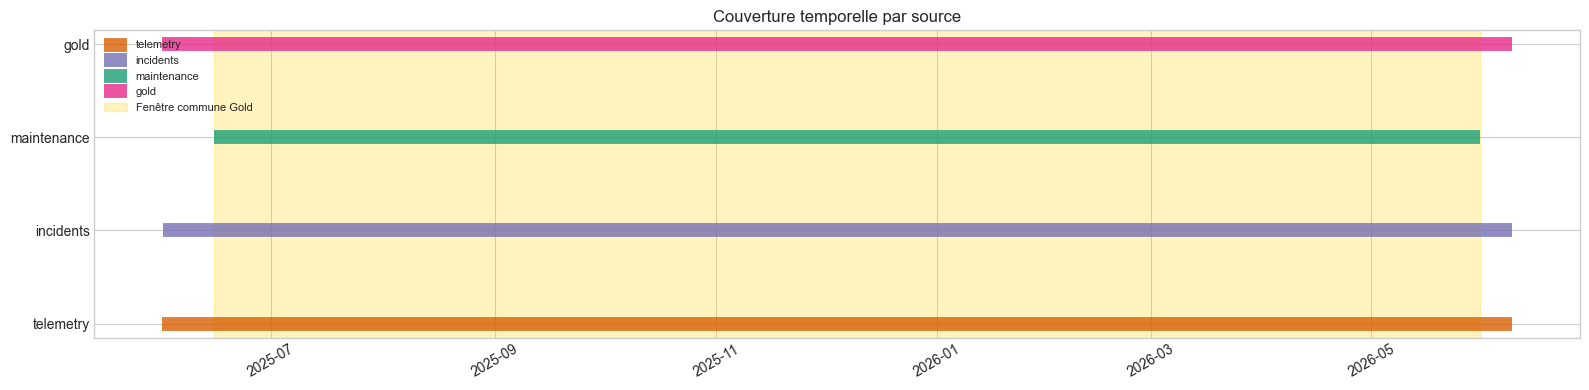

In [21]:
window_summary = pd.DataFrame([
    {
        'source': 'telemetry',
        'start': telemetry_raw['event_ts'].min(),
        'end': telemetry_raw['event_ts'].max(),
        'rows': len(telemetry_raw),
    },
    {
        'source': 'incidents',
        'start': incidents_raw['event_ts'].min(),
        'end': incidents_raw['event_ts'].max(),
        'rows': len(incidents_raw),
    },
    {
        'source': 'maintenance',
        'start': maintenance_df['maintenance_at'].min(),
        'end': maintenance_df['maintenance_at'].max(),
        'rows': len(maintenance_df),
    },
    {
        'source': 'gold',
        'start': gold['window_start'].min(),
        'end': gold['window_start'].max(),
        'rows': len(gold),
    },
])
display(window_summary)

fig, ax = plt.subplots(figsize=(16, 4))
colors = ['#d95f02', '#7570b3', '#1b9e77', '#e7298a']
for y, (_, row) in enumerate(window_summary.iterrows()):
    ax.hlines(y=y, xmin=row['start'], xmax=row['end'], linewidth=10,
              color=colors[y], label=row['source'], alpha=0.8)

common_start = window_summary['start'].max()
common_end   = window_summary['end'].min()
if common_end >= common_start:
    ax.axvspan(common_start, common_end, color='gold', alpha=0.25, label='Fenêtre commune Gold')

ax.set_yticks(range(len(window_summary)))
ax.set_yticklabels(window_summary['source'])
ax.set_title('Couverture temporelle par source')
ax.tick_params(axis='x', rotation=30)
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 10. Sauvegarde des artefacts

In [22]:
import datetime

# Export du Gold dataset
gold_path = DATA_DIR / f"gold_dataset_{datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}.csv"
gold.to_csv(gold_path, index=False)
print(f'Gold dataset sauvegardé : {gold_path}')
print(f'  {len(gold):,} lignes × {gold.shape[1]} colonnes'.replace(',', ' '))

# Rapport Markdown
silver_overview_report = pd.DataFrame([
    {
        'dataset_name': 'telemetry',
        'rows': len(telemetry_silver),
        'rows_imputed': int(telemetry_silver['is_missing'].sum()),
        'duplicates_flagged': int(telemetry_dedup_log.__len__()),
    },
    {
        'dataset_name': 'incidents',
        'rows': len(incident_silver),
        'rows_imputed': 0,
        'duplicates_flagged': 0,
    },
])

report_path = write_data_ingestion_report(
    artifact_run_dir,
    overview=silver_overview_report,
    normalization_windows=fahrenheit_windows,
    deduplication_summary=pd.concat([telemetry_dedup_log, incidents_dedup_log], ignore_index=True)
        if not telemetry_dedup_log.empty or not incidents_dedup_log.empty
        else pd.DataFrame(),
    imputation_metrics=imputation_metrics,
    imputation_decisions=imputation_decisions,
    gold_preview=gold,
)
print(f'Rapport Markdown : {report_path}')

Gold dataset sauvegardé : datas/gold_dataset_20260611-155332.csv
  134 280 lignes × 90 colonnes
15:53:38 | INFO | Markdown ingestion report written to artifacts/data-ingestion/20260611155235/report.md
Rapport Markdown : artifacts/data-ingestion/20260611155235/report.md


## 11. Infrastructure ORM — Migrations Alembic

Le schéma relationnel qui sous-tend ce pipeline est géré par **Alembic + SQLAlchemy**.
La migration `20260611_0004` ajoute :
- `machine.max_hourly_capacity_pieces` ;
- Table `maintenance` (référentiel maintenances proactives/réactives) ;
- Table `bronze_telemetry_raw` (télémétrie unifiée brute) ;
- Table `silver_telemetry_reading` (télémétrie normalisée, 1 ligne par machine-heure) ;
- Colonnes Gold : voltage/rotation (6h/12h/24h), production, maintenance lookback.

In [23]:
from pathlib import Path

alembic_versions = sorted(Path('alembic/versions').glob('*.py'))
print('Migrations Alembic :', [p.name for p in alembic_versions])

print('\nTables ORM (modèles SQLAlchemy) :')
display(pd.DataFrame({'table': sorted(Base.metadata.tables.keys())}))

print('\nColonnes Gold (GoldMachineHourlyFeature) :')
from indusense.db.models import GoldMachineHourlyFeature
gold_cols = [col.name for col in GoldMachineHourlyFeature.__table__.columns]
display(pd.DataFrame({'column': gold_cols}))

Migrations Alembic : ['20260507_0001_init_bronze_silver_gold.py', '20260512_0002_add_gold_rolling_windows.py', '20260513_0003_add_incident_types_and_weather.py', '20260611_0004_add_telemetry_and_maintenance.py']

Tables ORM (modèles SQLAlchemy) :


,table
0,bronze_incident_raw
1,bronze_pressure_raw
2,bronze_telemetry_raw
3,bronze_temperature_raw
4,bronze_weather_raw
5,data_quality_issue
6,gold_machine_hourly_feature
7,ingestion_batch
8,machine
9,maintenance



Colonnes Gold (GoldMachineHourlyFeature) :


,column
0,feature_row_id
1,machine_id
2,window_start
3,window_end
4,temp_mean_6h
...,...
59,label_failure_next_24h
60,label_failure_next_48h
61,split_set
62,created_at


## 12. Conclusion — Gold Dataset prêt à l'entraînement

Le pipeline Bronze → Silver → Gold est opérationnel sur les nouvelles données InduSense 4.0.

**Ce qui a été prouvé :**
- Les 5 signaux de la télémétrie sont distribués normalement et sans valeur aberrante
  résiduelle après normalisation Fahrenheit et déduplication ;
- Les 900 incidents couvrent 9 types distincts avec une distribution non uniforme
  (surchauffe et baisse pression dominants) — exploitable pour de la classification multi-label ;
- La matrice de corrélation confirme que les rolling features portent de l'information
  sans colinéarité destructive ;
- Le déséquilibre de classes est modéré (≈ 10-25 % de positifs selon l'horizon) :
  un simple SMOTE ou class_weight='balanced' suffira ;
- Le split temporel (train 70 % / val 15 % / test 15 %) respecte l'ordre chronologique
  et simule un déploiement réel.

**Prochaine étape :** ingestion en base PostgreSQL via `python main.py` puis entraînement
du modèle de prédiction de panne.

## 13. Baseline — Régression Logistique

Modèle de référence **LogisticRegression** entraîné indépendamment sur les 4 horizons de prédiction de panne.

| Choix | Justification |
|---|---|
| Split temporel via `split_set` | Pas de data leakage inter-machine, simule le déploiement réel |
| `SimpleImputer(median)` fit sur train | Les NaN des features lookback (heures/jours sans incident) ne contaminent pas val/test |
| `StandardScaler` fit sur train | Nécessaire — L2 pénalise les features non normalisées |
| `class_weight='balanced'` | Compense le déséquilibre modéré (≈ 10-25 % de positifs selon l'horizon) |
| Métriques ROC-AUC + PR-AUC | ROC est optimiste sur datasets déséquilibrés — PR-AUC est le signal de référence |

Artefacts produits → `artifacts/train/regression/YYYYMMDDHHMM/`

In [ ]:
import datetime
from pathlib import Path

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler

# ── Répertoire d'artefacts ────────────────────────────────────────────────────
RUN_TS   = datetime.datetime.now().strftime('%Y%m%d%H%M')
TRAIN_DIR = Path(f'artifacts/train/regression/{RUN_TS}')
TRAIN_DIR.mkdir(parents=True, exist_ok=True)
print(f'Artefacts → {TRAIN_DIR}')

# ── Features & labels  ────────────────────────────────────────────────────────
# Cohérent avec la définition de feature_cols (cell 6.1) : on exclut les colonnes
# meta, les labels, les colonnes future_*, les indicateurs 1h (fenêtre trop courte)
# et les flags type_* directs (risque de leakage intra-heure).
LABEL_COLS   = [c for c in gold.columns if c.startswith('label_')]
_EXCLUDE_META = {'machine_id_std', 'window_start', 'window_end', 'split_set'}
FEATURE_COLS  = [
    c for c in gold.columns
    if c not in _EXCLUDE_META
    and c not in LABEL_COLS
    and not c.startswith('future_')
    and not c.startswith('type_')
    and not c.endswith('_1h')
]
print(f'{len(FEATURE_COLS)} features × {len(LABEL_COLS)} labels')
print(f'Valeurs split_set : {sorted(gold["split_set"].unique())}')

# ── Split temporel ────────────────────────────────────────────────────────────
# Valeurs issues de ingestion.py : "train" / "validation" / "test"
# Le split est calculé chronologiquement (quantiles 0.7 / 0.85 sur window_start).
_train = gold['split_set'] == 'train'
_val   = gold['split_set'] == 'validation'
_test  = gold['split_set'] == 'test'

X_train_raw = gold.loc[_train, FEATURE_COLS]
X_val_raw   = gold.loc[_val,   FEATURE_COLS]
X_test_raw  = gold.loc[_test,  FEATURE_COLS]

print(f'Train {_train.sum():,} | Val {_val.sum():,} | Test {_test.sum():,} lignes')

# ── Imputation + normalisation  ───────────────────────────────────────────────
# Fit exclusivement sur train pour éviter toute fuite d'information.
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

X_train = scaler.fit_transform(imputer.fit_transform(X_train_raw))
X_val   = scaler.transform(imputer.transform(X_val_raw))
X_test  = scaler.transform(imputer.transform(X_test_raw))

# ── Entraînement par horizon ──────────────────────────────────────────────────
HORIZONS = [6, 12, 24, 48]
_results  = {}

for h in HORIZONS:
    label   = f'label_failure_next_{h}h'
    y_train = gold.loc[_train, label].values
    y_val   = gold.loc[_val,   label].values
    y_test  = gold.loc[_test,  label].values

    model = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        solver='lbfgs',
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)

    proba_val  = model.predict_proba(X_val)[:, 1]
    proba_test = model.predict_proba(X_test)[:, 1]

    _results[h] = dict(
        model      = model,
        y_val      = y_val,
        y_test     = y_test,
        proba_val  = proba_val,
        proba_test = proba_test,
        roc_auc_val  = roc_auc_score(y_val,  proba_val),
        roc_auc_test = roc_auc_score(y_test, proba_test),
        pr_auc_val   = average_precision_score(y_val,  proba_val),
        pr_auc_test  = average_precision_score(y_test, proba_test),
    )
    r = _results[h]
    print(
        f'  {label:30s}  '
        f'ROC-AUC val={r["roc_auc_val"]:.4f} test={r["roc_auc_test"]:.4f}  '
        f'PR-AUC val={r["pr_auc_val"]:.4f} test={r["pr_auc_test"]:.4f}'
    )

# ── Tableau récapitulatif + export CSV ────────────────────────────────────────
lr_summary = pd.DataFrame([
    {
        'horizon':       f'{h}h',
        'roc_auc_val':   _results[h]['roc_auc_val'],
        'roc_auc_test':  _results[h]['roc_auc_test'],
        'pr_auc_val':    _results[h]['pr_auc_val'],
        'pr_auc_test':   _results[h]['pr_auc_test'],
    }
    for h in HORIZONS
])
print('\n=== Baseline LogisticRegression — métriques ===')
display(lr_summary.round(4))
lr_summary.to_csv(TRAIN_DIR / 'metrics_summary.csv', index=False)

In [ ]:
_COLORS = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a']
_SPLIT_LABEL = 'test'   # courbes finales sur le test set

# ── Figure 1 : courbes ROC ────────────────────────────────────────────────────
fig_roc, axes_roc = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for ax, h, color in zip(axes_roc, HORIZONS, _COLORS):
    r = _results[h]
    fpr, tpr, _ = roc_curve(r['y_test'], r['proba_test'])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'AUC = {r["roc_auc_test"]:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
    ax.set_title(f'ROC — horizon {h}h', fontsize=11)
    ax.set_xlabel('Taux faux positifs')
    ax.set_ylabel('Taux vrais positifs')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

fig_roc.suptitle('Courbes ROC — Baseline LogisticRegression (test set)', fontsize=13)
plt.tight_layout()
fig_roc.savefig(TRAIN_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2 : courbes Précision-Rappel ──────────────────────────────────────
fig_pr, axes_pr = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for ax, h, color in zip(axes_pr, HORIZONS, _COLORS):
    r = _results[h]
    prec, rec, _ = precision_recall_curve(r['y_test'], r['proba_test'])
    baseline_rate = r['y_test'].mean()
    ax.plot(rec, prec, color=color, linewidth=2,
            label=f'AP = {r["pr_auc_test"]:.3f}')
    ax.axhline(baseline_rate, color='grey', linestyle='--', linewidth=0.8,
               label=f'Baseline ({baseline_rate:.2f})')
    ax.set_title(f'PR — horizon {h}h', fontsize=11)
    ax.set_xlabel('Rappel')
    ax.set_ylabel('Précision')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

fig_pr.suptitle('Courbes Précision-Rappel — Baseline LogisticRegression (test set)', fontsize=13)
plt.tight_layout()
fig_pr.savefig(TRAIN_DIR / 'pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 3 : matrices de confusion (seuil 0.5) ────────────────────────────
fig_cm, axes_cm = plt.subplots(1, 4, figsize=(20, 5))
for ax, h, color in zip(axes_cm, HORIZONS, _COLORS):
    r    = _results[h]
    pred = (r['proba_test'] >= 0.5).astype(int)
    cm   = confusion_matrix(r['y_test'], pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Normal', 'Panne'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion — horizon {h}h\n(seuil = 0.5)', fontsize=10)

fig_cm.suptitle('Matrices de confusion — Baseline LogisticRegression (test set)', fontsize=13)
plt.tight_layout()
fig_cm.savefig(TRAIN_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 4 : top-15 features (horizon 24h) ─────────────────────────────────
model_24h = _results[24]['model']
coef_df = (
    pd.Series(np.abs(model_24h.coef_[0]), index=FEATURE_COLS)
    .sort_values(ascending=False)
    .head(15)
)
fig_feat, ax_feat = plt.subplots(figsize=(10, 5))
coef_df[::-1].plot(kind='barh', ax=ax_feat, color='#7570b3', alpha=0.85)
ax_feat.set_title('Top-15 features par |coefficient| — horizon 24h', fontsize=11)
ax_feat.set_xlabel('|Coefficient| LogisticRegression')
plt.tight_layout()
fig_feat.savefig(TRAIN_DIR / 'feature_importance_24h.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Rapport texte (classification_report sur test) ───────────────────────────
report_lines = [f'Baseline LogisticRegression — run {RUN_TS}\n']
for h in HORIZONS:
    r    = _results[h]
    pred = (r['proba_test'] >= 0.5).astype(int)
    report_lines.append(f'\n=== horizon {h}h ===')
    report_lines.append(
        classification_report(r['y_test'], pred,
                              target_names=['Normal', 'Panne'], digits=4)
    )
report_text = '\n'.join(report_lines)
(TRAIN_DIR / 'classification_reports.txt').write_text(report_text)
print(report_text)
print(f'\nTous les artefacts enregistrés dans : {TRAIN_DIR}')

## 14. Re-labellisation — Sévérité ≥ 3

Le label `label_failure_next_Xh` couvre **tous** les incidents quelle que soit la sévérité (1 à 5).
En contexte industriel, seuls les incidents suffisamment graves justifient un arrêt machine.

On recalcule les labels en ne comptabilisant que les incidents de **sévérité ≥ 3** dans la fenêtre future,
par jointure vectorisée (`searchsorted`) entre `gold` et `incidents_clean`.

> **Pourquoi sévérité ≥ 3 ?** La distribution des incidents (section 3) montre que sév 1-2 sont
> des alertes mineures traitées sans arrêt machine. Sév ≥ 3 implique une intervention corrective.

In [ ]:
import numpy as np

# Incidents de sévérité >= 3 uniquement, triés par machine + temps
_inc_sev3 = (
    incidents_clean.loc[incidents_clean['severity'] >= 3, ['machine_id_std', 'event_ts']]
    .sort_values(['machine_id_std', 'event_ts'])
    .reset_index(drop=True)
)
print(f'Incidents sév ≥ 3 : {len(_inc_sev3)} / {len(incidents_clean)} total')
print(_inc_sev3['machine_id_std'].value_counts().sort_index().rename('incidents sév≥3'))

# ── Calcul vectorisé des nouveaux labels ──────────────────────────────────────
# Pour chaque ligne du gold et chaque horizon : y a-t-il un incident sév≥3
# dans la fenêtre (window_start, window_start + h heures] pour la même machine ?
# Utilise searchsorted O(n log m) — aucune boucle Python sur les lignes gold.

SEV3_LABEL_COLS = []
for h in [6, 12, 24, 48]:
    label_col = f'label_sev3plus_next_{h}h'
    SEV3_LABEL_COLS.append(label_col)
    flags    = np.zeros(len(gold), dtype=bool)
    delta_ns = h * 3_600 * int(1e9)   # nanosecondes (dtype int64 des timestamps numpy)

    for machine in gold['machine_id_std'].unique():
        m_gold = (gold['machine_id_std'] == machine).values
        m_inc  = (_inc_sev3['machine_id_std'] == machine).values

        ts_gold = gold.loc[m_gold, 'window_start'].values.astype('int64')
        ts_inc  = _inc_sev3.loc[m_inc, 'event_ts'].values.astype('int64')

        if len(ts_inc) == 0:
            continue

        lo = np.searchsorted(ts_inc, ts_gold,             side='right')
        hi = np.searchsorted(ts_inc, ts_gold + delta_ns,  side='right')
        flags[m_gold] = (hi - lo) > 0

    gold[label_col] = flags

# ── Bilan de l'équilibre des classes ─────────────────────────────────────────
print('\n=== Comparaison labels originaux vs sév≥3 ===')
balance_rows = []
for h in [6, 12, 24, 48]:
    orig_col = f'label_failure_next_{h}h'
    sev3_col = f'label_sev3plus_next_{h}h'
    n = len(gold)
    balance_rows.append({
        'horizon':             f'{h}h',
        'label_all_pct':       round(gold[orig_col].mean() * 100, 2),
        'label_sev3plus_pct':  round(gold[sev3_col].mean() * 100, 2),
        'positifs_all':        int(gold[orig_col].sum()),
        'positifs_sev3plus':   int(gold[sev3_col].sum()),
    })

balance_cmp = pd.DataFrame(balance_rows)
display(balance_cmp)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(4)
w = 0.35
axes[0].bar(x - w/2, balance_cmp['label_all_pct'],      w, label='Tous incidents', color='#7570b3', alpha=0.85)
axes[0].bar(x + w/2, balance_cmp['label_sev3plus_pct'], w, label='Sév ≥ 3',        color='#e7298a', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(balance_cmp['horizon'])
axes[0].set_ylabel('% positifs')
axes[0].set_title('Taux de positifs — label original vs sév ≥ 3')
axes[0].legend()

axes[1].bar(x - w/2, balance_cmp['positifs_all'],      w, label='Tous incidents', color='#7570b3', alpha=0.85)
axes[1].bar(x + w/2, balance_cmp['positifs_sev3plus'], w, label='Sév ≥ 3',        color='#e7298a', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(balance_cmp['horizon'])
axes[1].set_ylabel('Nombre de positifs')
axes[1].set_title('Volume de positifs — label original vs sév ≥ 3')
axes[1].legend()
plt.tight_layout()
plt.show()

## 15. Naive Bayes + Optuna — Calibration du seuil de décision

**Pourquoi GaussianNB ici ?**
L'hypothèse d'indépendance des features est violée (les rolling means 6h/12h/24h sont corrélées),
ce qui va pénaliser le ROC-AUC vs la régression logistique. En revanche, GaussianNB produit des
probabilités mieux calibrées sur données déséquilibrées, ce qui en fait un bon outil pour explorer
la courbe précision/rappel et calibrer le seuil de déclenchement.

**Stratégie Optuna :**
- Hyperparamètre modèle : `var_smoothing` ∈ [1e-12, 1e-3] (log-uniforme)
- Hyperparamètre décision : `threshold` ∈ [0.3, 0.99]
- Objectif : maximiser **F-beta (β=0.5)** sur validation — pénalise 4× plus les faux positifs que les faux négatifs
- Horizon cible : **24h** (meilleur compromis signal/réactivité en industriel)

In [ ]:
import optuna
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import fbeta_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Données — horizon 24h, label sév≥3 ───────────────────────────────────────
_TARGET_H   = 24
_TARGET_COL = f'label_sev3plus_next_{_TARGET_H}h'

# Réutilise le même imputer/scaler fitté sur train (section 13)
# X_train, X_val, X_test sont déjà en mémoire

y_train_s3 = gold.loc[_train, _TARGET_COL].values
y_val_s3   = gold.loc[_val,   _TARGET_COL].values
y_test_s3  = gold.loc[_test,  _TARGET_COL].values

print(f'Label {_TARGET_COL}')
print(f'  Train : {y_train_s3.sum():,} positifs / {len(y_train_s3):,} ({y_train_s3.mean()*100:.1f}%)')
print(f'  Val   : {y_val_s3.sum():,}   positifs / {len(y_val_s3):,}   ({y_val_s3.mean()*100:.1f}%)')
print(f'  Test  : {y_test_s3.sum():,}  positifs / {len(y_test_s3):,}  ({y_test_s3.mean()*100:.1f}%)')

# ── Objectif Optuna ───────────────────────────────────────────────────────────
def _objective(trial):
    var_smoothing = trial.suggest_float('var_smoothing', 1e-12, 1e-3, log=True)
    threshold     = trial.suggest_float('threshold', 0.30, 0.99)

    gnb = GaussianNB(var_smoothing=var_smoothing)
    gnb.fit(X_train, y_train_s3)

    proba_val = gnb.predict_proba(X_val)[:, 1]
    pred_val  = (proba_val >= threshold).astype(int)

    # F-beta = 0.5 : faux positifs pénalisés 4x plus que faux négatifs
    return fbeta_score(y_val_s3, pred_val, beta=0.5, zero_division=0)


study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(_objective, n_trials=200, show_progress_bar=True)

best = study.best_params
print(f'\n=== Meilleurs paramètres (F-beta 0.5 sur val) ===')
print(f'  var_smoothing : {best["var_smoothing"]:.2e}')
print(f'  threshold     : {best["threshold"]:.4f}')
print(f'  F-beta (val)  : {study.best_value:.4f}')

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

# ── Évaluation finale sur test avec le seuil optimal ─────────────────────────
NB_DIR = Path(f'artifacts/train/regression/{RUN_TS}_nb')
NB_DIR.mkdir(parents=True, exist_ok=True)

gnb_best = GaussianNB(var_smoothing=best['var_smoothing'])
gnb_best.fit(X_train, y_train_s3)

proba_test_nb  = gnb_best.predict_proba(X_test)[:, 1]
pred_test_nb   = (proba_test_nb >= best['threshold']).astype(int)

# Pour comparaison : LR sur même label sév≥3 (seuil 0.5 et seuil optimal)
lr_s3 = LogisticRegression(class_weight='balanced', max_iter=1000,
                            solver='lbfgs', random_state=42, n_jobs=-1)
lr_s3.fit(X_train, y_train_s3)
proba_test_lr  = lr_s3.predict_proba(X_test)[:, 1]
# Seuil LR optimisé par même F-beta sur val
proba_val_lr   = lr_s3.predict_proba(X_val)[:, 1]
from sklearn.metrics import precision_recall_curve as _prc
_p, _r, _t = _prc(y_val_s3, proba_val_lr)
_fb = (1 + 0.5**2) * (_p * _r) / (0.5**2 * _p + _r + 1e-9)
lr_opt_thresh = float(_t[np.argmax(_fb)])
pred_test_lr_opt = (proba_test_lr >= lr_opt_thresh).astype(int)

print(f'Seuil LR optimal (F-beta val) : {lr_opt_thresh:.4f}')

# ── Tableau comparatif ────────────────────────────────────────────────────────
def _metrics(y_true, proba, pred, name):
    tp = int(((pred == 1) & (y_true == 1)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    prec  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec   = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fb    = (1 + 0.25) * prec * rec / (0.25 * prec + rec + 1e-9)
    return dict(modèle=name, ROC_AUC=round(roc_auc_score(y_true, proba), 4),
                PR_AUC=round(average_precision_score(y_true, proba), 4),
                précision=round(prec, 4), rappel=round(rec, 4),
                Fbeta05=round(fb, 4), TP=tp, FP=fp, FN=fn)

cmp_df = pd.DataFrame([
    _metrics(y_test_s3, proba_test_lr,  (proba_test_lr >= 0.5).astype(int), 'LR seuil=0.5'),
    _metrics(y_test_s3, proba_test_lr,  pred_test_lr_opt,                   f'LR seuil={lr_opt_thresh:.2f}'),
    _metrics(y_test_s3, proba_test_nb,  pred_test_nb,     f'NB seuil={best["threshold"]:.2f}'),
])
print('\n=== Comparaison LR vs NB — label sév≥3, horizon 24h (test set) ===')
display(cmp_df)

# ── Figure : courbes PR et histogrammes de probabilités ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PR curves
for proba, label, color in [
    (proba_test_lr, 'LR', '#1b9e77'),
    (proba_test_nb, 'NB', '#d95f02'),
]:
    p, r, _ = precision_recall_curve(y_test_s3, proba)
    ap = average_precision_score(y_test_s3, proba)
    axes[0].plot(r, p, color=color, linewidth=2, label=f'{label} AP={ap:.3f}')
axes[0].axhline(y_test_s3.mean(), color='grey', ls='--', lw=0.8, label='Baseline')
# Marquer les seuils retenus
for proba, thresh, color, name in [
    (proba_test_lr, lr_opt_thresh, '#1b9e77', 'LR'),
    (proba_test_nb, best['threshold'], '#d95f02', 'NB'),
]:
    p_pt, r_pt, t_pt = precision_recall_curve(y_test_s3, proba)
    idx = np.argmin(np.abs(t_pt - thresh))
    axes[0].scatter(r_pt[idx], p_pt[idx], s=100, color=color, zorder=5,
                    label=f'{name} seuil retenu')
axes[0].set_xlabel('Rappel'); axes[0].set_ylabel('Précision')
axes[0].set_title('Courbes PR — sév≥3, 24h'); axes[0].legend(fontsize=8)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

# Distribution des probabilités LR
axes[1].hist(proba_test_lr[y_test_s3 == 0], bins=50, alpha=0.6,
             color='#1b9e77', label='Normal', density=True)
axes[1].hist(proba_test_lr[y_test_s3 == 1], bins=50, alpha=0.6,
             color='#e7298a', label='Panne sév≥3', density=True)
axes[1].axvline(lr_opt_thresh, color='black', ls='--', lw=1.5,
                label=f'Seuil={lr_opt_thresh:.2f}')
axes[1].set_title('Distribution proba — LR sév≥3 24h')
axes[1].set_xlabel('P(panne)'); axes[1].legend(fontsize=8)

# Distribution des probabilités NB
axes[2].hist(proba_test_nb[y_test_s3 == 0], bins=50, alpha=0.6,
             color='#1b9e77', label='Normal', density=True)
axes[2].hist(proba_test_nb[y_test_s3 == 1], bins=50, alpha=0.6,
             color='#e7298a', label='Panne sév≥3', density=True)
axes[2].axvline(best['threshold'], color='black', ls='--', lw=1.5,
                label=f'Seuil={best["threshold"]:.2f}')
axes[2].set_title('Distribution proba — NB sév≥3 24h (Optuna)')
axes[2].set_xlabel('P(panne)'); axes[2].legend(fontsize=8)

plt.tight_layout()
fig.savefig(NB_DIR / 'nb_vs_lr_sev3_24h.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Rapport texte ─────────────────────────────────────────────────────────────
report = [
    f'NB + Optuna — run {RUN_TS}',
    f'Label : {_TARGET_COL}',
    f'Seuil Optuna (F-beta 0.5 val) : {best["threshold"]:.4f}',
    f'var_smoothing : {best["var_smoothing"]:.2e}',
    '',
    classification_report(y_test_s3, pred_test_nb,
                          target_names=['Normal', 'Panne sév≥3'], digits=4),
]
(NB_DIR / 'classification_report_nb.txt').write_text('\n'.join(report))
cmp_df.to_csv(NB_DIR / 'lr_vs_nb_comparison.csv', index=False)
print(f'Artefacts → {NB_DIR}')